# Master Project

- Full name: Kaveh Hakimi Firooz
- Student ID: 5502674

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import matplotlib.colors as colors


## 1: Intelligent planning for container stacking (Discharge from vessel)
- Approach: Supervised Learning

### 1.1 Reading discharge dataset and data overview

In [3]:
###########################
# ddf = Discharge Data File
ddf = pd.read_csv("Discharge.csv")

In [4]:
ddf.head()

,ETA,VesselArrivalDate,VoyageNo,QCNo,ContainerNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel
0,9/2/2018 12:59,9/2/2018 7:45,49J,G7,TCNU606394-8,40',HC,1,Internal Transit,4200,2230.00,B2,20,1,1
1,9/7/2018 10:59,9/7/2018 8:00,17J,G5,TOLU484394-1,40',OT,1,Rajaee S.E.Z,4000,4000.00,OG3,1,1,1
2,9/11/2018 13:00,9/12/2018 1:37,INSY0227N,G3,SEGU928590-0,40',HRF,1,Import,4590,26271.47,R2,8,1,1
3,9/17/2018 23:59,9/17/2018 7:15,SAS1044N,G2,IRSU239212-9,20',DC,0,Import,2200,0.00,D8,8,1,1
4,9/18/2018 6:00,9/18/2018 7:10,INSY0228N,G5,SEGU946655-5,40',HRF,1,Import,4540,28098.47,R4,22,4,2


In [4]:
ddf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ETA                20000 non-null  object 
 1   VesselArrivalDate  20000 non-null  object 
 2   VoyageNo           20000 non-null  object 
 3   QCNo               20000 non-null  object 
 4   ContainerNo        20000 non-null  object 
 5   ContainerSize      20000 non-null  object 
 6   ContainerType      20000 non-null  object 
 7   ContainerStatus    20000 non-null  int64  
 8   ShipmentType       20000 non-null  object 
 9   TareWeight         20000 non-null  int64  
 10  NetWeight          20000 non-null  float64
 11  BlockName          20000 non-null  object 
 12  YardZoneRow        20000 non-null  int64  
 13  YardZoneTier       20000 non-null  int64  
 14  YardZoneLevel      20000 non-null  int64  
dtypes: float64(1), int64(5), object(9)
memory usage: 2.3+ MB


In [5]:
##########################################
# A short review of some data's statistics

ddf.describe()

,ContainerStatus,TareWeight,NetWeight,YardZoneRow,YardZoneTier,YardZoneLevel
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,0.900550,3249.916900,18763.031386,32.248200,2.603150,1.697050
std,0.299273,987.564585,9443.041797,19.334906,1.679197,0.902392
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,1.000000,2200.000000,14570.000000,16.000000,1.000000,1.000000
50%,1.000000,3840.000000,22801.500000,30.000000,2.000000,1.000000
75%,1.000000,4000.000000,25236.000000,48.000000,4.000000,2.000000
max,1.000000,6000.000000,398556.000000,75.000000,6.000000,4.000000


#### 1.1.1 Displaying the default value for discharge features

- **Total records and total features:**

In [6]:
number_of_records = ddf.shape[0]
number_of_features = ddf.shape[1]
print("Total records in the Discharge Dataset: {}".format(number_of_records))
print("Total features in the Discharge Dataset: {}".format(number_of_features))

Total records in the Discharge Dataset: 20000
Total features in the Discharge Dataset: 15


- **Total records broken down by container size:**

In [7]:
container_10_feet = ddf[ddf['ContainerSize'] == "10'"].shape[0]
container_20_feet = ddf[ddf['ContainerSize'] == "20'"].shape[0]
container_40_feet = ddf[ddf['ContainerSize'] == "40'"].shape[0]
container_45_feet = ddf[ddf['ContainerSize'] == "45'"].shape[0]
container_60_feet = ddf[ddf['ContainerSize'] == "60'"].shape[0]
total_sum_records = container_10_feet+container_20_feet+container_40_feet+container_45_feet+container_60_feet

print("The discharge dataset contains a total of {} 10-foot containers.".format(container_10_feet))
print("The discharge dataset contains a total of {} 20-foot containers.".format(container_20_feet))
print("The discharge dataset contains a total of {} 40-foot containers.".format(container_40_feet))
print("The discharge dataset contains a total of {} 45-foot containers.".format(container_45_feet))
print("The discharge dataset contains a total of {} 60-foot containers.".format(container_60_feet))
print("The discharge dataset contains a total of {} records in all container size.".format(total_sum_records))

The discharge dataset contains a total of 0 10-foot containers.
The discharge dataset contains a total of 9184 20-foot containers.
The discharge dataset contains a total of 10756 40-foot containers.
The discharge dataset contains a total of 60 45-foot containers.
The discharge dataset contains a total of 0 60-foot containers.
The discharge dataset contains a total of 20000 records in all container size.


- **Total records broken down by container status:**

In [8]:
full_container = ddf[ddf["ContainerStatus"] == 1].shape[0]
empty_container = ddf[ddf["ContainerStatus"] == 0].shape[0]
total_sum_records = full_container+empty_container

print("The discharge dataset contains a total of {} FULL containers.".format(full_container))
print("The discharge dataset contains a total of {} EMPTY containers.".format(empty_container))
print("The discharge dataset contains a total of {} records in all container status.".format(total_sum_records))

The discharge dataset contains a total of 18011 FULL containers.
The discharge dataset contains a total of 1989 EMPTY containers.
The discharge dataset contains a total of 20000 records in all container status.


- **Total records broken down by container type:**

In [9]:
dc_container = ddf[ddf["ContainerType"] == "DC"].shape[0]
dg_container = ddf[ddf["ContainerType"] == "DG"].shape[0]
flt_container = ddf[ddf["ContainerType"] == "FLT"].shape[0]
hc_container = ddf[ddf["ContainerType"] == "HC"].shape[0]
hrf_container = ddf[ddf["ContainerType"] == "HRF"].shape[0]
og_container = ddf[ddf["ContainerType"] == "OG"].shape[0]
ot_container = ddf[ddf["ContainerType"] == "OT"].shape[0]
rf_container = ddf[ddf["ContainerType"] == "RF"].shape[0]
tnk_container = ddf[ddf["ContainerType"] == "TNK"].shape[0]
total_sum_records = dc_container+dg_container+flt_container+hc_container+hrf_container+og_container+ot_container+\
rf_container+tnk_container

print("The discharge dataset contains a total of {} DC containers.".format(dc_container))
print("The discharge dataset contains a total of {} DG containers.".format(dg_container))
print("The discharge dataset contains a total of {} FLT containers.".format(flt_container))
print("The discharge dataset contains a total of {} HC containers.".format(hc_container))
print("The discharge dataset contains a total of {} HRF containers.".format(hrf_container))
print("The discharge dataset contains a total of {} OG containers.".format(og_container))
print("The discharge dataset contains a total of {} OT containers.".format(ot_container))
print("The discharge dataset contains a total of {} RF containers.".format(rf_container))
print("The discharge dataset contains a total of {} TNK containers.".format(tnk_container))
print("The discharge dataset contains a total of {} records in all container type.".format(total_sum_records))


The discharge dataset contains a total of 10119 DC containers.
The discharge dataset contains a total of 16 DG containers.
The discharge dataset contains a total of 220 FLT containers.
The discharge dataset contains a total of 7746 HC containers.
The discharge dataset contains a total of 895 HRF containers.
The discharge dataset contains a total of 49 OG containers.
The discharge dataset contains a total of 124 OT containers.
The discharge dataset contains a total of 789 RF containers.
The discharge dataset contains a total of 42 TNK containers.
The discharge dataset contains a total of 20000 records in all container type.


- **Total records broken down by shipment type:**

In [10]:
import_container = ddf[ddf["ShipmentType"] == "Import"].shape[0]
external_transit_container = ddf[ddf["ShipmentType"] == "External Transit"].shape[0]
internal_transit_container = ddf[ddf["ShipmentType"] == "Internal Transit"].shape[0]
external_tranship_container = ddf[ddf["ShipmentType"] == "External Tranship"].shape[0]
internal_tranship_container = ddf[ddf["ShipmentType"] == "Internal Tranship"].shape[0]
sez_container = ddf[ddf["ShipmentType"] == "Rajaee S.E.Z"].shape[0]
total_sum_records =import_container+external_transit_container+internal_transit_container+external_tranship_container+\
internal_tranship_container+sez_container

print("The discharge dataset contains a total of {} Import containers.".format(import_container))
print("The discharge dataset contains a total of {} External Transit containers.".format(external_transit_container))
print("The discharge dataset contains a total of {} Internal Transit containers.".format(internal_transit_container))
print("The discharge dataset contains a total of {} External Tranship containers.".format(external_tranship_container))
print("The discharge dataset contains a total of {} Internal Tranship containers.".format(internal_tranship_container))
print("The discharge dataset contains a total of {} Echonomical Zone containers.".format(sez_container))
print("The discharge dataset contains a total of {} records in all shipment type.".format(total_sum_records))

The discharge dataset contains a total of 7191 Import containers.
The discharge dataset contains a total of 2534 External Transit containers.
The discharge dataset contains a total of 649 Internal Transit containers.
The discharge dataset contains a total of 6044 External Tranship containers.
The discharge dataset contains a total of 1221 Internal Tranship containers.
The discharge dataset contains a total of 2361 Echonomical Zone containers.
The discharge dataset contains a total of 20000 records in all shipment type.


- **Total discharged containers broken down by Quay Crane:**

In [11]:
G1_QC = ddf[ddf["QCNo"] == "G1"].shape[0]
G2_QC = ddf[ddf["QCNo"] == "G2"].shape[0]
G3_QC = ddf[ddf["QCNo"] == "G3"].shape[0]
G4_QC = ddf[ddf["QCNo"] == "G4"].shape[0]
G5_QC = ddf[ddf["QCNo"] == "G5"].shape[0]
G6_QC = ddf[ddf["QCNo"] == "G6"].shape[0]
G7_QC = ddf[ddf["QCNo"] == "G7"].shape[0]
G8_QC = ddf[ddf["QCNo"] == "G8"].shape[0]
G9_QC = ddf[ddf["QCNo"] == "G9"].shape[0]
G10_QC = ddf[ddf["QCNo"] == "G10"].shape[0]
G11_QC = ddf[ddf["QCNo"] == "G11"].shape[0]
G12_QC = ddf[ddf["QCNo"] == "G12"].shape[0]
G13_QC = ddf[ddf["QCNo"] == "G13"].shape[0]
G14_QC = ddf[ddf["QCNo"] == "G14"].shape[0]
G15_QC = ddf[ddf["QCNo"] == "G15"].shape[0]
G16_QC = ddf[ddf["QCNo"] == "G16"].shape[0]
G17_QC = ddf[ddf["QCNo"] == "G17"].shape[0]
G18_QC = ddf[ddf["QCNo"] == "G18"].shape[0]

print("The discharge dataset contains a total of {} containers discharged by G1 Quay Crane.".format(G1_QC))
print("The discharge dataset contains a total of {} containers discharged by G2 Quay Crane.".format(G2_QC))
print("The discharge dataset contains a total of {} containers discharged by G3 Quay Crane.".format(G3_QC))
print("The discharge dataset contains a total of {} containers discharged by G4 Quay Crane.".format(G4_QC))
print("The discharge dataset contains a total of {} containers discharged by G5 Quay Crane.".format(G5_QC))
print("The discharge dataset contains a total of {} containers discharged by G6 Quay Crane.".format(G6_QC))
print("The discharge dataset contains a total of {} containers discharged by G7 Quay Crane.".format(G7_QC))
print("The discharge dataset contains a total of {} containers discharged by G8 Quay Crane.".format(G8_QC))
print("The discharge dataset contains a total of {} containers discharged by G9 Quay Crane.".format(G9_QC))
print("The discharge dataset contains a total of {} containers discharged by G10 Quay Crane.".format(G10_QC))
print("The discharge dataset contains a total of {} containers discharged by G11 Quay Crane.".format(G11_QC))
print("The discharge dataset contains a total of {} containers discharged by G12 Quay Crane.".format(G12_QC))
print("The discharge dataset contains a total of {} containers discharged by G13 Quay Crane.".format(G13_QC))
print("The discharge dataset contains a total of {} containers discharged by G14 Quay Crane.".format(G14_QC))
print("The discharge dataset contains a total of {} containers discharged by G15 Quay Crane.".format(G15_QC))
print("The discharge dataset contains a total of {} containers discharged by G16 Quay Crane.".format(G16_QC))
print("The discharge dataset contains a total of {} containers discharged by G17 Quay Crane.".format(G17_QC))
print("The discharge dataset contains a total of {} containers discharged by G18 Quay Crane.".format(G18_QC))


The discharge dataset contains a total of 671 containers discharged by G1 Quay Crane.
The discharge dataset contains a total of 1198 containers discharged by G2 Quay Crane.
The discharge dataset contains a total of 1485 containers discharged by G3 Quay Crane.
The discharge dataset contains a total of 1836 containers discharged by G4 Quay Crane.
The discharge dataset contains a total of 2209 containers discharged by G5 Quay Crane.
The discharge dataset contains a total of 3814 containers discharged by G6 Quay Crane.
The discharge dataset contains a total of 3728 containers discharged by G7 Quay Crane.
The discharge dataset contains a total of 3189 containers discharged by G8 Quay Crane.
The discharge dataset contains a total of 0 containers discharged by G9 Quay Crane.
The discharge dataset contains a total of 12 containers discharged by G10 Quay Crane.
The discharge dataset contains a total of 8 containers discharged by G11 Quay Crane.
The discharge dataset contains a total of 253 cont

- **Sample discharged containers into some blocks:**

In [12]:
B2_Block = ddf[ddf["BlockName"] == "B2"].shape[0]
OG3_Block = ddf[ddf["BlockName"] == "OG3"].shape[0]
R2_Block = ddf[ddf["BlockName"] == "R2"].shape[0]
D8_Block = ddf[ddf["BlockName"] == "D8"].shape[0]

print("<<Sample discharged containet into some blocks>>\n")
print("The discharge dataset contains a total of {} containers discharged into B2 Block.".format(B2_Block))
print("The discharge dataset contains a total of {} containers discharged into OG3 Block.".format(OG3_Block))
print("The discharge dataset contains a total of {} containers discharged into R2 Block.".format(R2_Block))
print("The discharge dataset contains a total of {} containers discharged into D8 Block.".format(D8_Block))


<<Sample discharged containet into some blocks>>

The discharge dataset contains a total of 3 containers discharged into B2 Block.
The discharge dataset contains a total of 52 containers discharged into OG3 Block.
The discharge dataset contains a total of 214 containers discharged into R2 Block.
The discharge dataset contains a total of 681 containers discharged into D8 Block.


- **Sample discharged cotainers into a specific block and yard zone:**

In [13]:
A4Block = ddf[(ddf["BlockName"] == "A4") & (ddf["YardZoneRow"] == 2)].shape[0]

print("<<Sample discharged containet into an specific block and yard zone>>\n")
print("The discharged containers into Block A4 and the second Yard Zone Row: {}".format(A4Block))


<<Sample discharged containet into an specific block and yard zone>>

The discharged containers into Block A4 and the second Yard Zone Row: 18


### 1.2 Data Cleaning

- Handle missing values
- Dropping useless features
- Dropping duplicates
- Deal with outliers
- Handle categorical variables
- Data normalization


#### 1.2.1 Dropping Null values:

In [14]:
######################
# Checking Null values
print(ddf.isnull().sum())

ETA                  0
VesselArrivalDate    0
VoyageNo             0
QCNo                 0
ContainerNo          0
ContainerSize        0
ContainerType        0
ContainerStatus      0
ShipmentType         0
TareWeight           0
NetWeight            0
BlockName            0
YardZoneRow          0
YardZoneTier         0
YardZoneLevel        0
dtype: int64


In [15]:
######################
# Dropping Null values

print("Number of records before drop null values:", len(ddf))
ddf = ddf.dropna()
print("Number of records after drop null values:", len(ddf))

Number of records before drop null values: 20000
Number of records after drop null values: 20000


#### 1.2.2 Impute missing values:

In [16]:
print("<<Impute missing values for Net Weight:>>")
missing_before = ddf['NetWeight'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ddf['NetWeight'].fillna(ddf['NetWeight'].mean(), inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ddf['NetWeight'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)

<<Impute missing values for Net Weight:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [17]:
print("<<Impute missing values for Tare Weight:>>")
missing_before = ddf['TareWeight'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ddf['TareWeight'].fillna(ddf['TareWeight'].mean(), inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ddf['TareWeight'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)

<<Impute missing values for Tare Weight:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [18]:
print("<<Impute missing values for Container Status:>>")
missing_before = ddf['ContainerStatus'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ddf['ContainerStatus'].fillna(ddf['ContainerStatus'].mean(), inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ddf['ContainerStatus'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)

<<Impute missing values for Container Status:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [19]:
print("<<Impute missing values for Container Type:>>")
missing_before = ddf['ContainerType'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

########################################################
# Impute missing values with mode (for categorical data)
ddf['ContainerType'].fillna(ddf['ContainerType'].mode()[0], inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ddf['ContainerType'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)

<<Impute missing values for Container Type:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [20]:
print("<<Impute missing values for Container Size:>>")
missing_before = ddf['ContainerSize'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

########################################################
# Impute missing values with mode (for categorical data)
ddf['ContainerSize'].fillna(ddf['ContainerSize'].mode()[0], inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ddf['ContainerSize'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)

<<Impute missing values for Container Size:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


#### 1.2.3 Removing duplicates

In [21]:
################################
# check duplicates and remove it
duplicate = ddf.duplicated().sum()
print("Before removing duplicates:", duplicate)

if duplicate>0:
    ddf = ddf[~df.duplicated()]
    print("After removing duplicates:", ddf.duplicated().sum())

Before removing duplicates: 0


#### 1.2.4 Removing the Apostrophe character from the ContainerSize column across the dataset:

In [22]:
#########################################################
# displaying the dataset prior to deleting the apostrophe
ddf.head(2)

,ETA,VesselArrivalDate,VoyageNo,QCNo,ContainerNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel
0,9/2/2018 12:59,9/2/2018 7:45,49J,G7,TCNU606394-8,40',HC,1,Internal Transit,4200,2230.0,B2,20,1,1
1,9/7/2018 10:59,9/7/2018 8:00,17J,G5,TOLU484394-1,40',OT,1,Rajaee S.E.Z,4000,4000.0,OG3,1,1,1


In [23]:
import re

#################################################################
# Removing the Apostrophe character from the ContainerSize column
def remove_apostrophe(x):
    if isinstance(x, (int, float)):
        return x
    else:
        return re.sub("'", '', x)

ddf.loc[:, 'ContainerSize'] = ddf['ContainerSize'].apply(remove_apostrophe).astype(int)

In [24]:
######################################################
# displaying the dataset after deleting the apostrophe
ddf.head(2)

,ETA,VesselArrivalDate,VoyageNo,QCNo,ContainerNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel
0,9/2/2018 12:59,9/2/2018 7:45,49J,G7,TCNU606394-8,40,HC,1,Internal Transit,4200,2230.0,B2,20,1,1
1,9/7/2018 10:59,9/7/2018 8:00,17J,G5,TOLU484394-1,40,OT,1,Rajaee S.E.Z,4000,4000.0,OG3,1,1,1


#### 1.2.5 Removing leading and following spaces from the data file

In [25]:
###############################################################################
# removing leading and following spaces from the data file's chosen column only

columns = ['VoyageNo', 'QCNo', 'ContainerNo', 'ContainerSize', 'ContainerType', 'ShipmentType', 'BlockName']
for i in columns:
    ddf[i] = ddf[i].astype(str).str.strip()

In [26]:
ddf.ContainerType.value_counts()

DC     10119
HC      7746
HRF      895
RF       789
FLT      220
OT       124
OG        49
TNK       42
DG        16
Name: ContainerType, dtype: int64

In [27]:
ddf.ShipmentType.value_counts()

Import               7191
External Tranship    6044
External Transit     2534
Rajaee S.E.Z         2361
Internal Tranship    1221
Internal Transit      649
Name: ShipmentType, dtype: int64

### 1.3 Data Exploration

In [28]:
ddf.values

array([['9/2/2018 12:59', '9/2/2018 7:45', '49J', ..., 20, 1, 1],
       ['9/7/2018 10:59', '9/7/2018 8:00', '17J', ..., 1, 1, 1],
       ['9/11/2018 13:00', '9/12/2018 1:37', 'INSY0227N', ..., 8, 1, 1],
       ...,
       ['6/28/2019 8:00', '6/28/2019 8:00', '26', ..., 22, 2, 2],
       ['6/28/2019 8:00', '6/28/2019 8:00', '26', ..., 13, 1, 1],
       ['6/28/2019 8:00', '6/28/2019 8:00', '26', ..., 13, 1, 1]],
      dtype=object)

In [29]:
##########################################
# A short review of some data's statistics
ddf.describe()

,ContainerStatus,TareWeight,NetWeight,YardZoneRow,YardZoneTier,YardZoneLevel
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,0.900550,3249.916900,18763.031386,32.248200,2.603150,1.697050
std,0.299273,987.564585,9443.041797,19.334906,1.679197,0.902392
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,1.000000,2200.000000,14570.000000,16.000000,1.000000,1.000000
50%,1.000000,3840.000000,22801.500000,30.000000,2.000000,1.000000
75%,1.000000,4000.000000,25236.000000,48.000000,4.000000,2.000000
max,1.000000,6000.000000,398556.000000,75.000000,6.000000,4.000000


#### 1.3.1 Illustrate the link between Container Size, Container Type, and Shipment Type for discharged containers using a 3D bar plot.

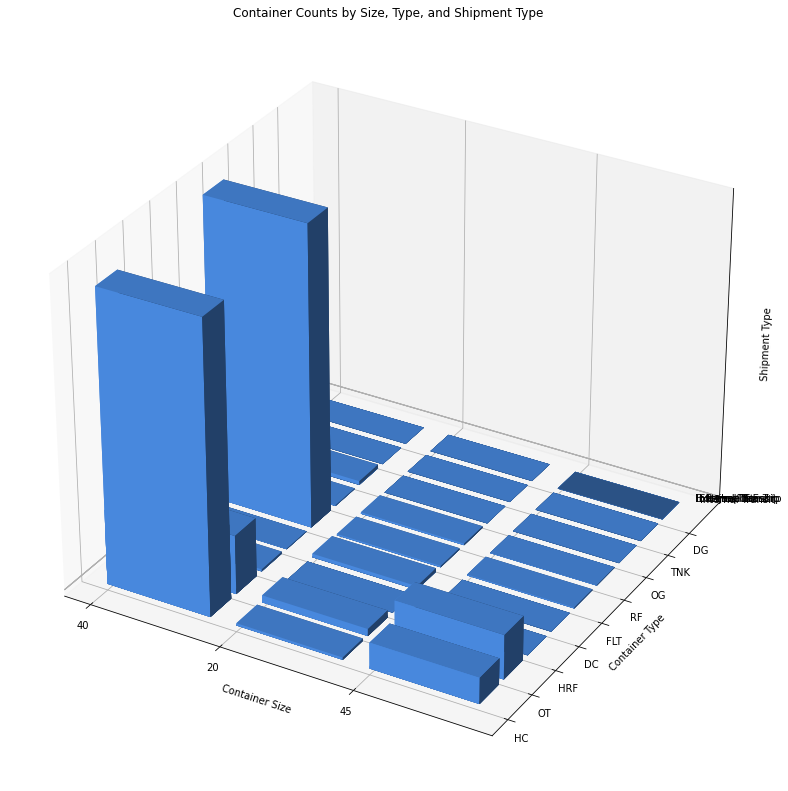

In [30]:
############################################
# Extract the relevant columns from the data
container_sizes = ddf['ContainerSize'].unique()
container_types = ddf['ContainerType'].unique()
shipment_types = ddf['ShipmentType'].unique()

###########################################################################################
# Generate container counts for each combination of container size, type, and shipment type
container_counts = np.zeros((len(container_sizes), len(container_types), len(shipment_types)))

for i, size in enumerate(container_sizes):
    for j, ctype in enumerate(container_types):
        for k, stype in enumerate(shipment_types):
            count = len(ddf[(ddf['ContainerSize'] == size) &
                             (ddf['ContainerType'] == ctype) &
                             (ddf['ShipmentType'] == stype)])
            container_counts[i, j, k] = count
######################
# Create a 3D bar plot
fig = plt.figure(figsize=[16, 14])
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = np.meshgrid(np.arange(len(container_sizes)),
                                  np.arange(len(container_types)),
                                  np.arange(len(shipment_types)))

x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = z_pos.flatten()
#######################################################
# Flatten the counts array to match the position arrays
counts = container_counts.flatten()
########################
# Create the 3D bar plot
ax.bar3d(x_pos, y_pos, z_pos, 0.8, 0.8, counts, color='#519AFA')
#######################
# Set labels and titles
ax.set_xticks(np.arange(len(container_sizes)))
ax.set_yticks(np.arange(len(container_types)))
ax.set_zticks(np.arange(len(shipment_types)))
ax.set_xticklabels(container_sizes)
ax.set_yticklabels(container_types)
ax.set_zticklabels(shipment_types)
ax.set_xlabel('Container Size')
ax.set_ylabel('Container Type')
ax.set_zlabel('Shipment Type')
ax.set_title('Container Counts by Size, Type, and Shipment Type')

plt.show()


#### 1.3.2 Illustrate the link between Quay Crane, Container Size, and Container Status for discharged containers using a 3D bar plot.

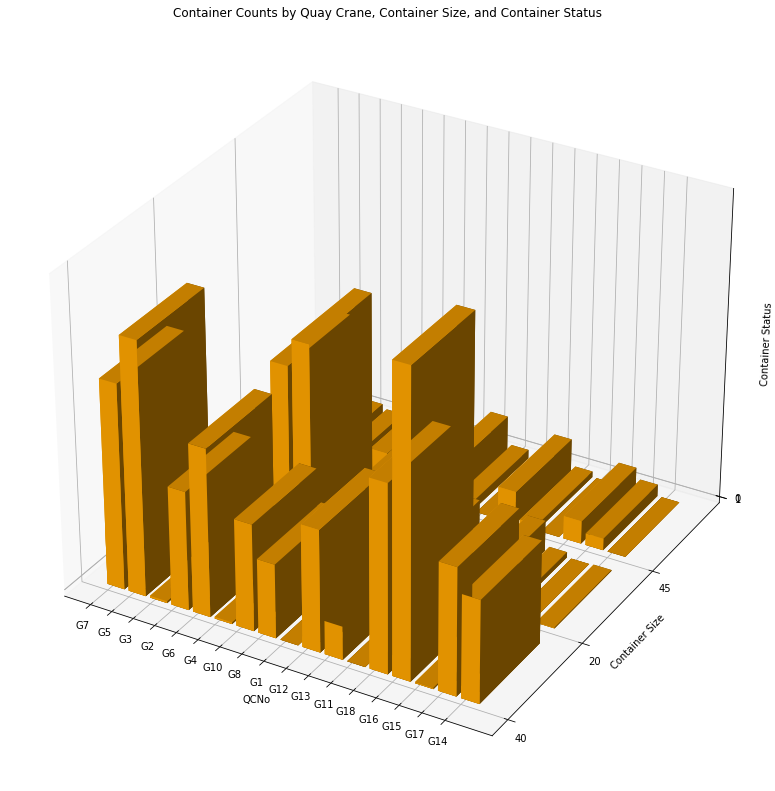

In [31]:
############################################
# Extract the relevant columns from the data
qc_numbers = ddf['QCNo'].unique()
container_sizes = ddf['ContainerSize'].unique()
container_status = ddf['ContainerStatus'].unique()

##############################################################################################
# Generate container counts for each combination of QCNo, Container Size, and Container Status
container_counts = np.zeros((len(qc_numbers), len(container_sizes), len(container_status)))

for i, qcno in enumerate(qc_numbers):
    for j, size in enumerate(container_sizes):
        for k, status in enumerate(container_status):
            count = len(ddf[(ddf['QCNo'] == qcno) &
                             (ddf['ContainerSize'] == size) &
                             (ddf['ContainerStatus'] == status)])
            container_counts[i, j, k] = count
######################
# Create a 3D bar plot
fig = plt.figure(figsize=[16, 14])
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = np.meshgrid(np.arange(len(qc_numbers)),
                                  np.arange(len(container_sizes)),
                                  np.arange(len(container_status)))

x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = z_pos.flatten()
#######################################################
# Flatten the counts array to match the position arrays
counts = container_counts.flatten()
########################
# Create the 3D bar plot
ax.bar3d(x_pos, y_pos, z_pos, 0.8, 0.8, counts, color='Orange')
#######################
# Set labels and titles
ax.set_xticks(np.arange(len(qc_numbers)))
ax.set_yticks(np.arange(len(container_sizes)))
ax.set_zticks(np.arange(len(container_status)))
ax.set_xticklabels(qc_numbers)
ax.set_yticklabels(container_sizes)
ax.set_zticklabels(container_status)
ax.set_xlabel('QCNo')
ax.set_ylabel('Container Size')
ax.set_zlabel('Container Status')
ax.set_title('Container Counts by Quay Crane, Container Size, and Container Status')

plt.show()


#### 1.3.3 Illustrate the link between Container Size, Container Type, and Container Status for discharged containers using a 3D bar plot.

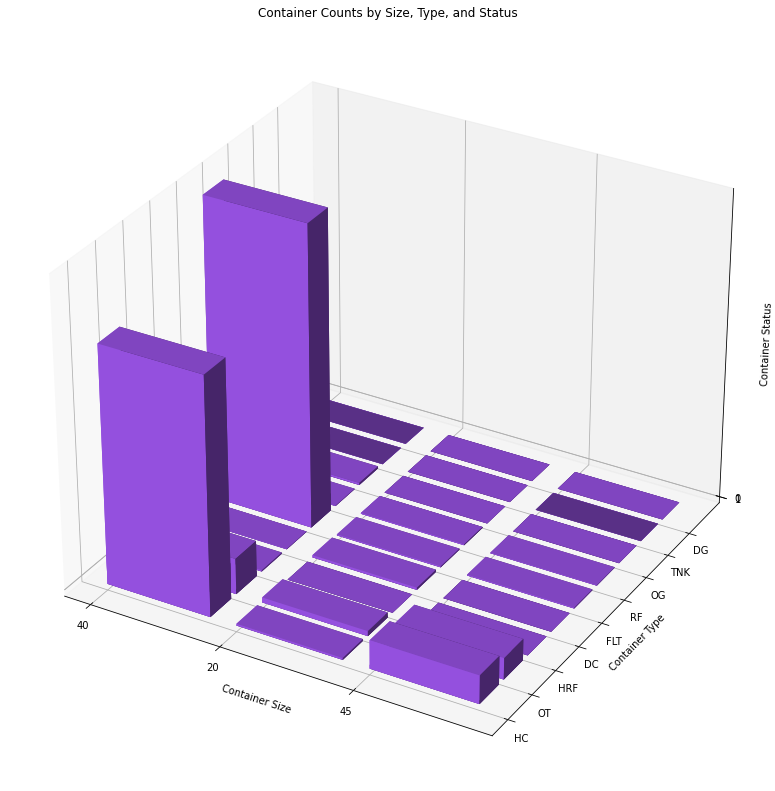

In [32]:
############################################
# Extract the relevant columns from the data
container_sizes = ddf['ContainerSize'].unique()
container_types = ddf['ContainerType'].unique()
container_status = ddf['ContainerStatus'].unique()

####################################################################################
# Generate container counts for each combination of container size, type, and status
container_counts = np.zeros((len(container_sizes), len(container_types), len(container_status)))

for i, size in enumerate(container_sizes):
    for j, ctype in enumerate(container_types):
        for k, status in enumerate(container_status):
            count = len(ddf[(ddf['ContainerSize'] == size) &
                             (ddf['ContainerType'] == ctype) &
                             (ddf['ContainerStatus'] == status)])
            container_counts[i, j, k] = count
######################
# Create a 3D bar plot
fig = plt.figure(figsize=[16, 14])
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = np.meshgrid(np.arange(len(container_sizes)),
                                  np.arange(len(container_types)),
                                  np.arange(len(container_status)))

x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = z_pos.flatten()
#######################################################
# Flatten the counts array to match the position arrays
counts = container_counts.flatten()
########################
# Create the 3D bar plot
ax.bar3d(x_pos, y_pos, z_pos, 0.8, 0.8, counts, color='#A75AFB')
#######################
# Set labels and titles
ax.set_xticks(np.arange(len(container_sizes)))
ax.set_yticks(np.arange(len(container_types)))
ax.set_zticks(np.arange(len(container_status)))
ax.set_xticklabels(container_sizes)
ax.set_yticklabels(container_types)
ax.set_zticklabels(container_status)
ax.set_xlabel('Container Size')
ax.set_ylabel('Container Type')
ax.set_zlabel('Container Status')
ax.set_title('Container Counts by Size, Type, and Status')

plt.show()


#### 1.3.4 Illustrate the link between Container Size and Container Type for discharged containers using a 2D heatmap diagram.

- This graph illustrates how many containers there are in a 2D environment, broken down by container type and size. The graph shows that the majority of the containers are DC and 20 in size. In addition, the smallest of the containers is 45 square feet in size.

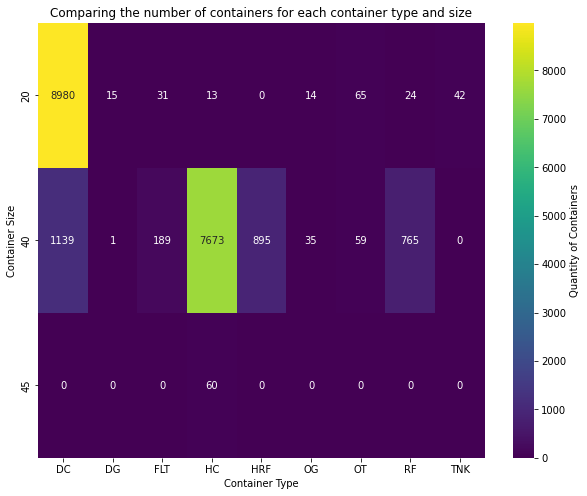

In [33]:
#####################
# Creating a heat map

#########################
# Define a list of colors
my_colors = ['#FF0000', '#00FF00', '#0000FF']

############################################################
# Create a custom colormap using the ListedColormap function
my_cmap = colors.ListedColormap(my_colors)

plt.figure(figsize=[10,8])
 
ct_counts = ddf.groupby(['ContainerSize', 'ContainerType']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'ContainerSize', columns = 'ContainerType', values = 'count').fillna(0)

sb.heatmap(ct_counts, annot = True, fmt = '.0f', cbar_kws = {'label' : 'Quantity of Containers'}, cmap = 'viridis')
plt.title('Comparing the number of containers for each container type and size')
plt.xlabel('Container Type')
plt.ylabel('Container Size');

#### 1.3.5 Illustrate the connection between the discharged container's Net Weight and Shipment Type, using a bar chart.

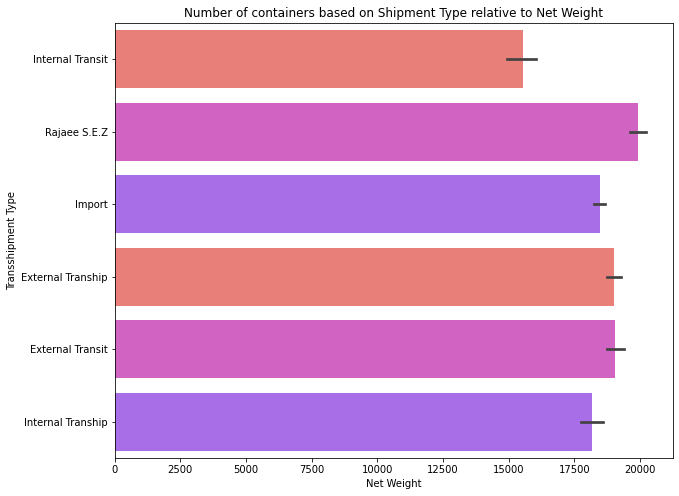

In [34]:
####################
# Creating Bar Chart 
plt.figure(figsize=[10,8])
custom_colors = ['#FA7066', '#E352CF', '#A75AFB']  # Replace with your desired colors
sb.barplot(data=ddf, x='NetWeight', y='ShipmentType', palette=custom_colors)
plt.title('Number of containers based on Shipment Type relative to Net Weight')
plt.xlabel('Net Weight')
plt.ylabel('Transshipment Type');

#### 1.3.6 Illustrate the connection between the discharged container's Net Weight and different Quay Cranes in the port, using a bar chart.

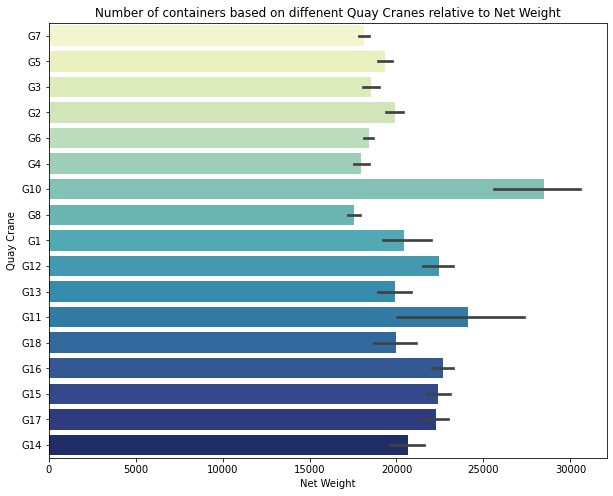

In [35]:
####################
# Creating Bar Chart 

plt.figure(figsize=[10,8])
sb.barplot(data=ddf, x='NetWeight', y='QCNo', palette='YlGnBu')
plt.title('Number of containers based on diffenent Quay Cranes relative to Net Weight')
plt.xlabel('Net Weight')
plt.ylabel('Quay Crane');

#### 1.3.7 Illustrate the connection between the discharged container's Tare Weight and different Quay Cranes in the port, using a bar chart.

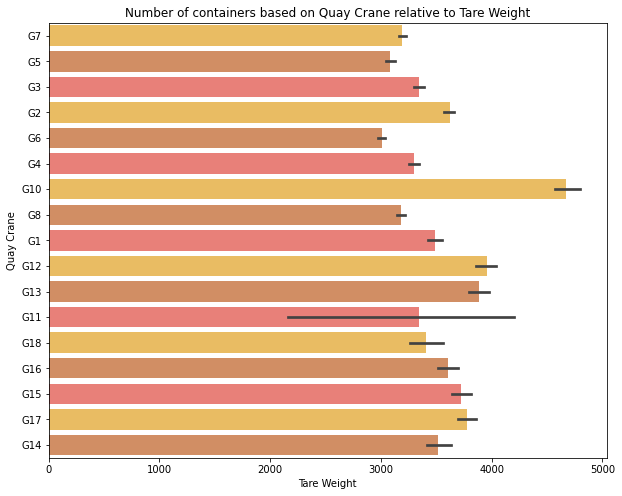

In [36]:
####################
# Creating Bar Chart 

plt.figure(figsize=[10,8])
custom_colors = ['#FFC34D', '#E38A52', '#FA7066']  # Replace with your desired colors
sb.barplot(data=ddf, x='TareWeight', y='QCNo', palette=custom_colors)
plt.title('Number of containers based on Quay Crane relative to Tare Weight')
plt.xlabel('Tare Weight')
plt.ylabel('Quay Crane')
plt.show()

### 1.4 Data Preprocessing

In this part, we will preprocess data so we create a copy of the primary data file named **ddf** to **ddf_pp**. Preprocess operations that we are going to do fall into some major categories:
- Preprocess Block Name as the class label;
- Drop more unnecessary features;
- Convert categorical features to numerical features;
- Convert class label to numerical; and
- Drop duplicate rows.

#### 1.4.1 Creating a copy of Discharge data file for preprocessing

In [37]:
ddf_pp = ddf.copy()

#### 1.4.2 Analyzing the container yard's block names as the most crucial class label.

In [38]:
ddf_pp['BlockName'].value_counts().sort_index(ascending=True)

A4      457
A5      841
A6       18
A7     1079
B2        3
B3        1
B4     1060
B5     1176
B6      114
B7     3081
B8      178
BC3       2
C2        1
C4      242
C5      372
C6        7
C7     2953
C8      887
D2       82
D3        2
D4      481
D5      803
D6       73
D7     2932
D8      681
E4      389
E5      263
KN       14
OG0     112
OG1      57
OG2      31
OG3      52
OG4      66
OG7      78
OG8     237
R1      212
R2      214
R3      117
R4      196
R5      204
R6      232
Name: BlockName, dtype: int64

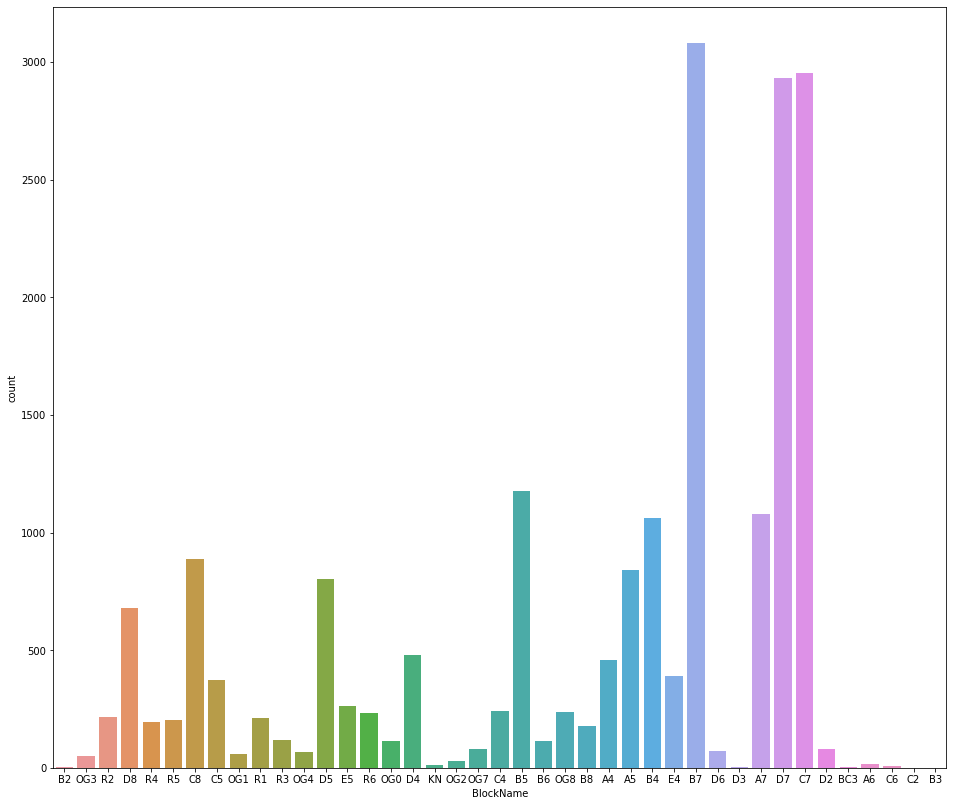

In [39]:
##############################################
# Creating a bar chart based on the Block Name

plt.figure(figsize=[16,14])
sb.countplot(x='BlockName', data=ddf_pp)
plt.show()

#### 1.4.3 Analyzing Quay Cranes of the berth as one of the most crucial input features.

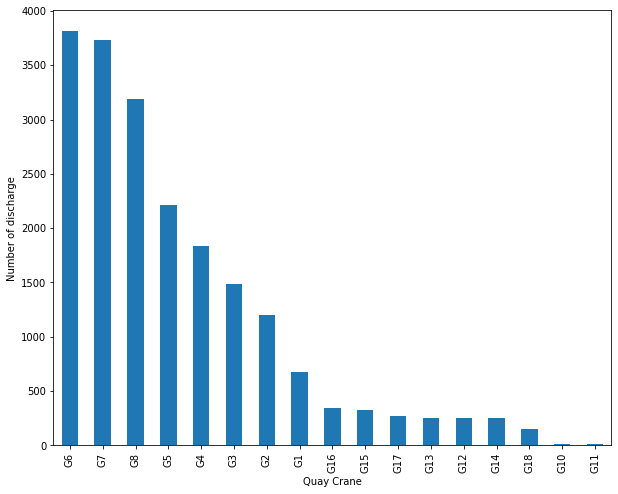

In [40]:
##############################################
# Creating a bar chart based on the Quay Crane

plt.figure(figsize=[10,8])
ddf_pp['QCNo'].value_counts().plot(kind='bar')
plt.xlabel('Quay Crane')
plt.ylabel('Number of discharge')
plt.show()

#### 1.4.4 Removing pointless features

In [41]:
###################################
# Dropping pointless input features

ddf_pp.drop('ContainerNo', inplace=True, axis=1)
ddf_pp.drop('ETA', inplace=True, axis=1)
ddf_pp.drop('VesselArrivalDate', inplace=True, axis=1)

In [42]:
ddf_pp.head()

,VoyageNo,QCNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel
0,49J,G7,40,HC,1,Internal Transit,4200,2230.00,B2,20,1,1
1,17J,G5,40,OT,1,Rajaee S.E.Z,4000,4000.00,OG3,1,1,1
2,INSY0227N,G3,40,HRF,1,Import,4590,26271.47,R2,8,1,1
3,SAS1044N,G2,20,DC,0,Import,2200,0.00,D8,8,1,1
4,INSY0228N,G5,40,HRF,1,Import,4540,28098.47,R4,22,4,2


#### 1.4.5 Converting categorical features to numerical

In [43]:
###############################################
# Converting Container Type to numerical values
ddf_pp['ContainerType'] = ddf_pp.ContainerType.replace({"DC": 1, "DG": 2, "OG": 3, "OT": 4, "RF": 5,\
                                                        "HRF": 6, "FLT": 7, "HC": 8, "TNK": 9})

##############################################
# Converting Shipment Type to numerical values
ddf_pp['ShipmentType'] = ddf_pp.ShipmentType.replace({"Import": 1, "External Transit": 2, "Internal Transit": 3,\
                                                      "External Tranship": 4, "Internal Tranship": 5, "Rajaee S.E.Z": 6})

###########################################
# Converting Quay Crane to numerical values
ddf_pp['QCNo'] = ddf_pp.QCNo.replace({"G1": 1, "G2": 2, "G3": 3, "G4": 4, "G5": 5, "G6": 6, "G7": 7, "G8": 8,\
                                      "G9": 9, "G10": 10, "G11": 11, "G12": 12, "G13": 13, "G14": 14, "G15": 15,\
                                      "G16": 16, "G17": 17, "G18": 18})

###########################################
# Converting Block Name to numerical values
ddf_pp['BlockName'] = ddf_pp.BlockName.replace({"A4": 1, "A5": 2, "A6": 3, "A7": 4, "B2": 5, "B3": 6, "B4": 7, "B5": 8,\
                                      "B6": 9, "B7": 10, "B8": 11, "BC3": 12, "C2": 13, "C4": 14, "C5": 15,\
                                      "C6": 16, "C7": 17, "C8": 18, "D2": 19, "D3": 20, "D4": 21, "D5": 22,\
                                           "D6": 23, "D7": 24, "D8": 25, "E4": 26, "E5": 27, "KN": 28,\
                                           "OG0": 29, "OG1": 30, "OG2": 31, "OG3": 32, "OG4": 33, "OG7": 34,\
                                           "OG8": 35, "R1": 36, "R2": 37, "R3": 38, "R4": 39, "R5": 40, "R6": 41})


In [44]:
from sklearn.preprocessing import LabelEncoder

#########################################
# Converting Voyage No to numerical value

#############################
# Initialize the LabelEncoder
encoder = LabelEncoder()

#########################################
# Fit and transform the 'VoyageNo' column
ddf_pp['VoyageNo'] = encoder.fit_transform(ddf_pp['VoyageNo'])


In [45]:
ddf_pp.head()

,VoyageNo,QCNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel
0,101,7,40,8,1,3,4200,2230.00,5,20,1,1
1,46,5,40,4,1,6,4000,4000.00,32,1,1,1
2,162,3,40,6,1,1,4590,26271.47,37,8,1,1
3,203,2,20,1,0,1,2200,0.00,25,8,1,1
4,163,5,40,6,1,1,4540,28098.47,39,22,4,2


#### 1.4.6 Dropping duplicate rows

In [46]:
duplicates = ddf_pp[ddf_pp.duplicated()]

##########################################################
# Generating a CSV file including duplicates for analyzing
duplicates.to_csv('discharge_duplicates.csv', index=False)

print(duplicates)

       VoyageNo  QCNo ContainerSize  ContainerType  ContainerStatus  \
8           113     4            20              4                1   
31           74     1            40              5                0   
89           79     5            20              4                1   
120          67     7            40              8                1   
138          74     1            40              5                0   
...         ...   ...           ...            ...              ...   
19986        65     7            20              1                1   
19991        65     7            20              1                1   
19994        65     7            20              1                1   
19995        65     7            20              1                1   
19997        65     8            20              1                1   

       ShipmentType  TareWeight  NetWeight  BlockName  YardZoneRow  \
8                 1        2200    22581.0         32           12   
31     

In [47]:
###########################################
# Dataset length before dropping duplicates
len(ddf_pp)

20000

In [48]:
#####################
# Dropping duplicates
ddf_pp.drop_duplicates(inplace=True)

In [49]:
###########################################
# Dataset length after dropping duplicates
len(ddf_pp)

16411

#### 1.4.7 Check zero values

In [50]:
########################################################
# Creating a list of only columns containing zero values
features_with_zero_values = ddf_pp.columns[(ddf_pp == 0).any()].tolist()

print(features_with_zero_values)

['VoyageNo', 'ContainerStatus', 'TareWeight', 'NetWeight']


- According to the context and nature of these four features, they can include zero values and there is no problem.

In [51]:
#######################################################
# Creating a list of all columns containing zero values
zero_value_counts_per_feature = (ddf_pp == 0).sum()

print("Number of records with zero values per feature:")
print(zero_value_counts_per_feature)

Number of records with zero values per feature:
VoyageNo             8
QCNo                 0
ContainerSize        0
ContainerType        0
ContainerStatus    564
ShipmentType         0
TareWeight          10
NetWeight          471
BlockName            0
YardZoneRow          0
YardZoneTier         0
YardZoneLevel        0
dtype: int64


### 1.5 Experimental Process

- Our scenario for Random Forest classifier in this part of project is **multi-label classification**.

#### 1.5.1 Random Forest Classifier to predict Block Name (Step 1 of Multi-label Classification)

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

################################################
# Separate the target variable from the features
X = ddf_pp.drop('BlockName', axis=1)
y = ddf_pp['BlockName']

###############################################
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#############################################################################
# Initialize the RandomForestClassifier model and fit it to the training data
rf_discharge = RandomForestClassifier(random_state=42)
rf_discharge.fit(X_train, y_train)

#///////////////////////////////////////////////////////
# Predict the target variable using the original dataset
predicted_block_name = rf_discharge.predict(X)  # Predicting for the entire dataset

ddf_pp.reset_index(drop=True, inplace=True)

# Create a new DataFrame to hold the original dataset with the predicted "Block Name" labels
predicted_block_df = pd.concat([ddf_pp, pd.Series(predicted_block_name, name='PredictedBlockName')], axis=1)
#///////////////////////////////////////////////////////

####################################################
# Predict the target variable using the training set
y_train_pred = rf_discharge.predict(X_train)

###################################################
# Predict the target variable using the testing set
y_test_pred = rf_discharge.predict(X_test)

##########
# ACCURACY
#########################################################
# Calculate the accuracy of the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
#########################################################
# Calculate the accuracy of the model on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)

###############################
# PRECISION, RECALL, & F1 SCORE
###############################################################
# Calculate precision, recall, and F1 score on the training set
train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=1)
train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=1)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
##############################################################
# Calculate precision, recall, and F1 score on the testing set
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=1)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')


print("Random Forest Algorithm for <<Block Name>>:")
print("-------------------")
print("Accuracy on training set:", train_accuracy)
print("Accuracy on testing set:", test_accuracy)
print("-------------------")
print("Precision on training set:", train_precision)
print("Precision on testing set:", test_precision)
print("-------------------")
print("Recall on training set:", train_recall)
print("Recall on testing set:", test_recall)
print("-------------------")
print("F1 score on training set:", train_f1)
print("F1 score on testing set:", test_f1)


Random Forest Algorithm for <<Block Name>>:
-------------------
Accuracy on training set: 0.9964198659354052
Accuracy on testing set: 0.8403898872982029
-------------------
Precision on training set: 0.9948256410345279
Precision on testing set: 0.8168381332483012
-------------------
Recall on training set: 0.9902205122860599
Recall on testing set: 0.7149784830177067
-------------------
F1 score on training set: 0.9923169400056843
F1 score on testing set: 0.7384577811690293


- **Test model with real data:**

In [53]:
#########################################
# Printing Prediction for the sample data
predictions = rf_discharge.predict([[203,2,20,1,0,1,2200,0,8,1,1], [183,6,40,6,1,6,4640,29049.82,18,3,1],\
                                    [183,5,40,5,1,1,4000,26505.40,4,3,1], [70,10,40,6,1,6,4620,28612.83,2,6,1],\
                                    [74,1,40,5,0,1,4230,0.00,30,1,1], [167,1,20,1,1,1,2200,19706.00,10,1,2]])
predictions

###################################
# Expected Answers: [25, 39, 40, 40, 18, 28]

C:\Users\Kavehoda\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([35, 39, 40, 40, 18, 28], dtype=int64)

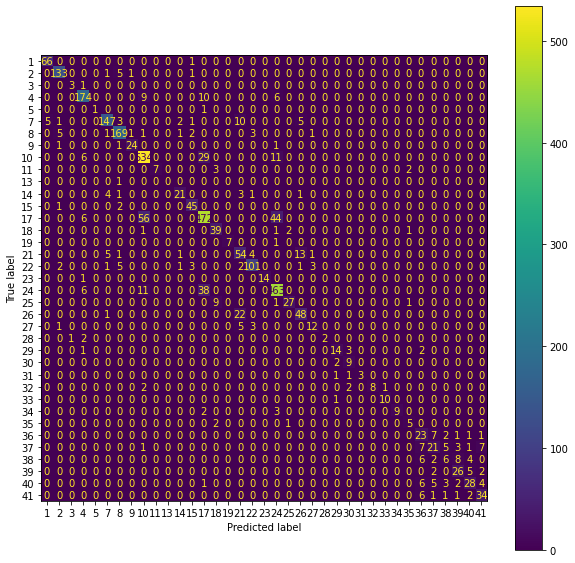

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

############################################################
# Drawing a matrix to analyze the Random Forest model result

###################################################
# Predict the target variable using the testing set
y_test_pred = rf_discharge.predict(X_test)
################################
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
###########################
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

disp.plot(ax=ax)
plt.show()


#### 1.5.2 Data normalization and standardization on the new Data File for predicting YardZoneRow.

In [55]:
############################
# Reindexing Block data file
predicted_block_df.reset_index(drop=True, inplace=True)

In [56]:
predicted_block_df.head()

,VoyageNo,QCNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,PredictedBlockName
0,101,7,40,8,1,3,4200,2230.00,5,20,1,1,17
1,46,5,40,4,1,6,4000,4000.00,32,1,1,1,32
2,162,3,40,6,1,1,4590,26271.47,37,8,1,1,37
3,203,2,20,1,0,1,2200,0.00,25,8,1,1,35
4,163,5,40,6,1,1,4540,28098.47,39,22,4,2,39


In [57]:
#################################################
# Creating a copy of Block data file to rename it
ddf_pp_yardzone = predicted_block_df.copy()

In [58]:
################################
# Converting features to integer
ddf_pp_yardzone['YardZoneRow'] = ddf_pp_yardzone['YardZoneRow'].astype(int)
ddf_pp_yardzone['YardZoneTier'] = ddf_pp_yardzone['YardZoneTier'].astype(int)
ddf_pp_yardzone['YardZoneLevel'] = ddf_pp_yardzone['YardZoneLevel'].astype(int)

In [59]:
########################################################################################
# Creating function to standardize columns of data file based on Z_Score standardization

def z_score_standardization(df, columns):
    for col in columns:
        #########################################################
        # Calculate the mean and standard deviation of the column
        mean = np.mean(df[col])
        std_dev = np.std(df[col])
        #######################################################################################
        # Standardize the column by subtracting the mean and dividing by the standard deviation
        df[col] = (df[col] - mean) / std_dev

In [60]:
z_score_standardization(ddf_pp_yardzone, ['YardZoneRow', 'YardZoneTier', 'YardZoneLevel'])

In [61]:
######################################
# Again Converting features to integer

ddf_pp_yardzone['YardZoneRow'] = ddf_pp_yardzone['YardZoneRow'].astype(int)
ddf_pp_yardzone['YardZoneTier'] = ddf_pp_yardzone['YardZoneTier'].astype(int)
ddf_pp_yardzone['YardZoneLevel'] = ddf_pp_yardzone['YardZoneLevel'].astype(int)

ddf_pp_yardzone.head()

,VoyageNo,QCNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,PredictedBlockName
0,101,7,40,8,1,3,4200,2230.00,5,0,-1,0,17
1,46,5,40,4,1,6,4000,4000.00,32,-1,-1,0,32
2,162,3,40,6,1,1,4590,26271.47,37,-1,-1,0,37
3,203,2,20,1,0,1,2200,0.00,25,-1,-1,0,35
4,163,5,40,6,1,1,4540,28098.47,39,0,0,0,39


In [62]:
#####################
# Checking duplicates
duplicates = ddf_pp_yardzone[ddf_pp_yardzone.duplicated()]
len(duplicates)

2631

In [63]:
############################################
# Data file before after dropping duplicates

len(ddf_pp_yardzone)

16411

In [64]:
###########################
# Dropping duplicate values
ddf_pp_yardzone.drop_duplicates(inplace=True)

In [65]:
############################################
# Data file length after dropping duplicates

len(ddf_pp_yardzone)

13780

#### 1.5.3 Random Forest Classifier to predict Yard Zone Row (Step 2 of Multi-label Classification)

In [66]:
################################################
# Separate the target variable from the features
X = ddf_pp_yardzone.drop('YardZoneRow', axis=1)
y = ddf_pp_yardzone['YardZoneRow']

###############################################
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#############################################################################
# Initialize the RandomForestClassifier model and fit it to the training data
rf_yardzone = RandomForestClassifier(random_state=42)
rf_yardzone.fit(X_train, y_train)

####################################################
# Predict the target variable using the training set
y_train_pred = rf_yardzone.predict(X_train)

###################################################
# Predict the target variable using the testing set
y_test_pred = rf_yardzone.predict(X_test)

##########
# ACCURACY
#########################################################
# Calculate the accuracy of the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
#########################################################
# Calculate the accuracy of the model on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)

###############################
# PRECISION, RECALL, & F1 SCORE
###############################################################
# Calculate precision, recall, and F1 score on the training set
train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=1)
train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=1)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
##############################################################
# Calculate precision, recall, and F1 score on the testing set
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=1)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Random Forest Algorithm for <<Yard Zone Row>>:")
print("-------------------")
print("Accuracy on training set:", train_accuracy)
print("Accuracy on testing set:", test_accuracy)
print("-------------------")
print("Precision on training set:", train_precision)
print("Precision on testing set:", test_precision)
print("-------------------")
print("Recall on training set:", train_recall)
print("Recall on testing set:", test_recall)
print("-------------------")
print("F1 score on training set:", train_f1)
print("F1 score on testing set:", test_f1)


Random Forest Algorithm for <<Yard Zone Row>>:
-------------------
Accuracy on training set: 0.9552793904208998
Accuracy on testing set: 0.6759796806966618
-------------------
Precision on training set: 0.9537984334550038
Precision on testing set: 0.6031985177980578
-------------------
Recall on training set: 0.9247743521576758
Recall on testing set: 0.5468652754956058
-------------------
F1 score on training set: 0.9386122782373081
F1 score on testing set: 0.5694260479783441


#### 1.5.4 Decision Tree Classifier to predict Block Name

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

################################################
# Separate the target variable from the features
X = ddf_pp.drop('BlockName', axis=1)
y = ddf_pp['BlockName']

###############################################
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#############################################################################
# Initialize the DecisionTreeClassifier model and fit it to the training data
dt_discharge = DecisionTreeClassifier(random_state=42)
dt_discharge.fit(X_train, y_train)

####################################################
# Predict the target variable using the training set
y_train_pred = dt_discharge.predict(X_train)
###################################################
# Predict the target variable using the testing set
y_test_pred = dt_discharge.predict(X_test)

##########
# ACCURACY
# Calculate the accuracy of the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
########################################################
# Calculate the accuracy of the model on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)

#################################
# precision, recall, and F1 score
# Calculate precision, recall, and F1 score on the training set
train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=1)
train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=1)
train_f1 = f1_score(y_train, y_train_pred, average='macro')

# Calculate precision, recall, and F1 score on the testing set
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=1)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Decision Tree Algorithm:")
print("-------------------")
print("Accuracy on training set:", train_accuracy)
print("Accuracy on testing set:", test_accuracy)
print("-------------------")
print("Precision on training set:", train_precision)
print("Precision on testing set:", test_precision)
print("-------------------")
print("Recall on training set:", train_recall)
print("Recall on testing set:", test_recall)
print("-------------------")
print("F1 score on training set:", train_f1)
print("F1 score on testing set:", test_f1)


Decision Tree Algorithm:
-------------------
Accuracy on training set: 0.9964960390006093
Accuracy on testing set: 0.8093207432226622
-------------------
Precision on training set: 0.9921457528605073
Precision on testing set: 0.6898625362142448
-------------------
Recall on training set: 0.9937234437462965
Recall on testing set: 0.6745969325480763
-------------------
F1 score on training set: 0.9927083016166833
F1 score on testing set: 0.6458348320091511


- **Test model with real data:**

In [68]:
#########################################
# Printing Prediction for the sample data
predictions = dt_discharge.predict([[203,2,20,1,0.00,1,2200,0,8,1,1], [183,6,40,6,1,6,4640,29049.82,18,3,1], [183,5,40,5,1,1,4000,26505.40,4,3,1], [70,10,40,6,1,6,4620,28612.83,2,6,1], [74,1,40,5,0,1,4230,0.00,30,1,1], [167,1,20,1,1,1,2200,19706.00,10,1,2]])
predictions

############################################
# Expected Answers: [25, 39, 40, 40, 18, 28]

C:\Users\Kavehoda\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([35, 39, 40, 40, 18, 28], dtype=int64)

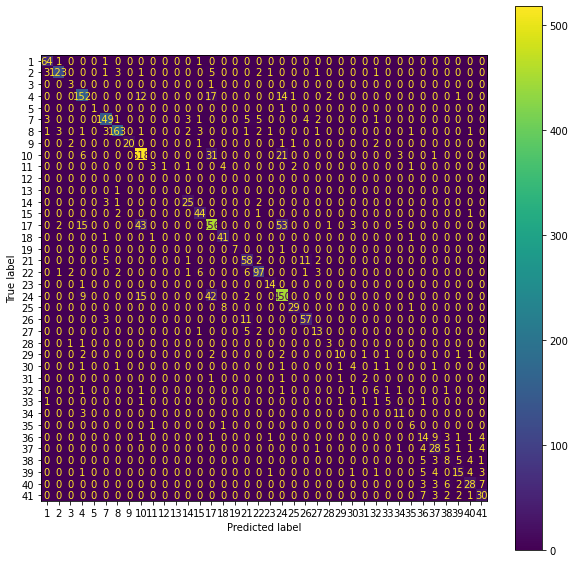

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

###################################################
# Predict the target variable using the testing set
y_test_pred = dt_discharge.predict(X_test)

################################
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

##################################################################
# Get the unique classes from the true labels and predicted labels
classes = np.unique(np.concatenate((y_test, y_test_pred)))

###########################
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(ax=ax)
plt.show()


#### 1.5.5 Ada Boost Classifier to predict Block Name

In [70]:
from sklearn.ensemble import AdaBoostClassifier

################################################
# Separate the target variable from the features
X = ddf_pp.drop('BlockName', axis=1)
y = ddf_pp['BlockName']

###############################################
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#########################################################################
# Initialize the AdaBoostClassifier model and fit it to the training data
ada_discharge = AdaBoostClassifier(random_state=42)
ada_discharge.fit(X_train, y_train)
####################################################
# Predict the target variable using the training set
y_train_pred = ada_discharge.predict(X_train)
###################################################
# Predict the target variable using the testing set
y_test_pred = ada_discharge.predict(X_test)

##########
# ACCURACY
#########################################################
# Calculate the accuracy of the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
########################################################
# Calculate the accuracy of the model on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)

#################################
# precision, recall, and F1 score
###############################################################
# Calculate precision, recall, and F1 score on the training set
train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=1)
train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=1)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
##############################################################
# Calculate precision, recall, and F1 score on the testing set
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=1)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Ada Boost Algorithm:")
print("-------------------")
print("Accuracy on training set:", train_accuracy)
print("Accuracy on testing set:", test_accuracy)
print("-------------------")
print("Precision on training set:", train_precision)
print("Precision on testing set:", test_precision)
print("-------------------")
print("Recall on training set:", train_recall)
print("Recall on testing set:", test_recall)
print("-------------------")
print("F1 score on training set:", train_f1)
print("F1 score on testing set:", test_f1)


Ada Boost Algorithm:
-------------------
Accuracy on training set: 0.25083790371724557
Accuracy on testing set: 0.2512945476698142
-------------------
Precision on training set: 0.7997807246260125
Precision on testing set: 0.7785629997122075
-------------------
Recall on training set: 0.07007973390687006
Recall on testing set: 0.07291632500708302
-------------------
F1 score on training set: 0.0532277844107667
F1 score on testing set: 0.05282808748990179


- **Test model with real data:**

In [71]:
#########################################
# Printing Prediction for the sample data
predictions = ada_discharge.predict([[203,2,20,1,0.00,1,2200,0,8,1,1], [183,6,40,6,1,6,4640,29049.82,18,3,1], [183,5,40,5,1,1,4000,26505.40,4,3,1], [70,10,40,6,1,6,4620,28612.83,2,6,1], [74,1,40,5,0,1,4230,0.00,30,1,1], [167,1,20,1,1,1,2200,19706.00,10,1,2]])
predictions

###################################
# Expected Answers: [25, 39, 40, 40, 18, 28]

C:\Users\Kavehoda\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


array([25, 17, 17, 17, 18, 17], dtype=int64)

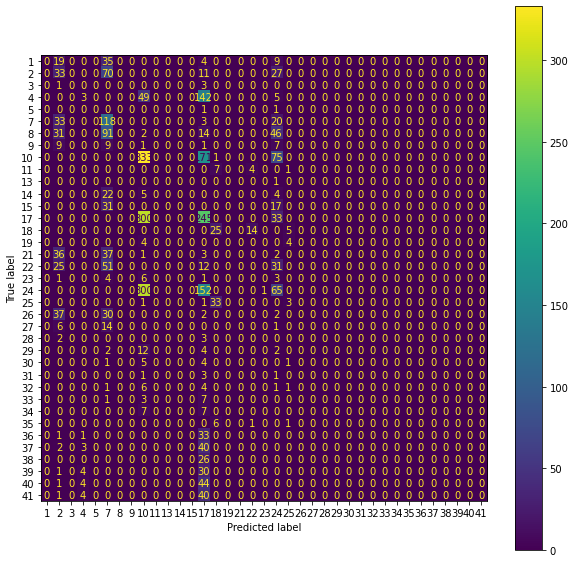

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

###################################################
# Predict the target variable using the testing set
y_test_pred = ada_discharge.predict(X_test)

################################
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

##################################################################
# Get the unique classes from the true labels and predicted labels
classes = np.unique(np.concatenate((y_test, y_test_pred)))

###########################
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax)
plt.show()


### 1.6 Feature Importance of Discharge dataset

In [73]:
from sklearn.preprocessing import LabelEncoder

In [74]:
###############################################################
# Creating a copy of Discharge data file for Feature Importance
ddf_fi = ddf.copy()

In [75]:
ddf_fi.head()

,ETA,VesselArrivalDate,VoyageNo,QCNo,ContainerNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel
0,9/2/2018 12:59,9/2/2018 7:45,49J,G7,TCNU606394-8,40,HC,1,Internal Transit,4200,2230.00,B2,20,1,1
1,9/7/2018 10:59,9/7/2018 8:00,17J,G5,TOLU484394-1,40,OT,1,Rajaee S.E.Z,4000,4000.00,OG3,1,1,1
2,9/11/2018 13:00,9/12/2018 1:37,INSY0227N,G3,SEGU928590-0,40,HRF,1,Import,4590,26271.47,R2,8,1,1
3,9/17/2018 23:59,9/17/2018 7:15,SAS1044N,G2,IRSU239212-9,20,DC,0,Import,2200,0.00,D8,8,1,1
4,9/18/2018 6:00,9/18/2018 7:10,INSY0228N,G5,SEGU946655-5,40,HRF,1,Import,4540,28098.47,R4,22,4,2


In [76]:
###############################################################################################
# Dropping pointless attributes for the Feature Importance process of Block Name as class label

ddf_fi.drop('ContainerNo', inplace=True, axis=1)
ddf_fi.drop('ETA', inplace=True, axis=1)
ddf_fi.drop('VesselArrivalDate', inplace=True, axis=1)
ddf_fi.drop('VoyageNo', inplace=True, axis=1)
ddf_fi.drop('YardZoneRow', inplace=True, axis=1)
ddf_fi.drop('YardZoneTier', inplace=True, axis=1)
ddf_fi.drop('YardZoneLevel', inplace=True, axis=1)


In [77]:
ddf_fi.columns.to_list()

['QCNo',
 'ContainerSize',
 'ContainerType',
 'ContainerStatus',
 'ShipmentType',
 'TareWeight',
 'NetWeight',
 'BlockName']

In [78]:
ddf_fi.head()

,QCNo,ContainerSize,ContainerType,ContainerStatus,ShipmentType,TareWeight,NetWeight,BlockName
0,G7,40,HC,1,Internal Transit,4200,2230.00,B2
1,G5,40,OT,1,Rajaee S.E.Z,4000,4000.00,OG3
2,G3,40,HRF,1,Import,4590,26271.47,R2
3,G2,20,DC,0,Import,2200,0.00,D8
4,G5,40,HRF,1,Import,4540,28098.47,R4


In [79]:
##############################################################################################################
# Iterating through DataFrame columns, applying label encoding to convert categorical data into numeric values.
for col in ddf_fi.columns:
    if ddf_fi[col].dtypes == 'object':
        encoder = LabelEncoder()
        ddf_fi[col] = encoder.fit_transform(ddf_fi[col])

In [80]:
#####################
# Partioning the data
Xc = ddf_fi.drop('BlockName', axis=1)
yc = ddf_fi['BlockName']

###################################
# Splitting to training and testing
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

In [81]:
rf_fi_discharge = RandomForestClassifier()
rf_fi_discharge.fit(Xc_train, yc_train)

#########################################################
# View a list of the features and their importance scores
print('\nFeatures Importance:')
feat_imp = pd.DataFrame(zip(Xc.columns.tolist(), rf_fi_discharge.feature_importances_ * 100), columns=['feature', 'importance'])
feat_imp


Features Importance:


,feature,importance
0,QCNo,19.156322
1,ContainerSize,1.638333
2,ContainerType,4.949268
3,ContainerStatus,3.438809
4,ShipmentType,11.499688
5,TareWeight,11.706716
6,NetWeight,47.610864


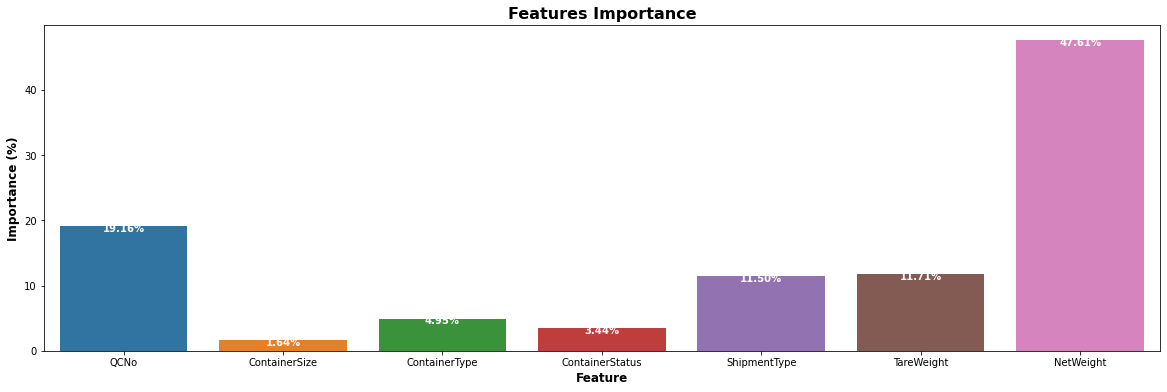

In [82]:
##########################
# Features importance plot
plt.figure(figsize=[20,6])
sb.barplot(data=feat_imp, x='feature', y='importance')
plt.title('Features Importance', weight='bold', fontsize=16)
plt.xlabel('Feature', weight='bold', fontsize=12)
plt.ylabel('Importance (%)', weight='bold', fontsize=12);

#################
# add annotations
impo = feat_imp['importance']
locs, labels = plt.xticks()

for loc, label in zip(locs, labels):
    count = impo[loc]
    pct_string = '{:0.2f}%'.format(count)

    plt.text(loc, count-0.8, pct_string, ha = 'center', color = 'w', weight='bold')

## 2: Intelligent planning for container stacking (Loading on the vessel)
- Approach: Supervised Learning

### 2.1 Reading loading dataset and data overview

In [83]:
#########################
# ldf = Loading Data File
ldf = pd.read_csv("Load.csv")

In [84]:
ldf.head()

,Container,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ArrivalDate,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo,LoadDate
0,AAAU900247-0,A6,24,1,1,2/8/2019 17:16,40',HC,1,Export,32202.0,AEJEA,G6,TDS75,6,2,84,2/11/2019 9:39
1,ACLU963509-0,C6,40,3,1,2/5/2019 9:00,40',HC,1,Export,26384.0,INMUN,G4,156,6,4,86,2/6/2019 15:20
2,AKLU600770-5,A4,25,1,2,4/7/2019 0:39,20',DC,1,External Tranship,3293.0,IRKHO,G7,1204,3,2,4,4/10/2019 2:43
3,AKLU650732-0,B6,30,2,1,4/21/2019 8:56,40',HC,1,Export,30510.0,AEJEA,G4,TDS89,6,3,84,4/23/2019 20:53
4,AKLU650836-9,B6,46,1,1,3/7/2019 20:18,40',HC,1,Export,28740.0,AEJEA,G1,01902J,2,0,84,3/8/2019 18:16


In [85]:
##########################
# A quick view of data set

ldf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Container        20000 non-null  object 
 1   BlockName        20000 non-null  object 
 2   YardZoneRow      20000 non-null  int64  
 3   YardZoneTier     20000 non-null  int64  
 4   YardZoneLevel    20000 non-null  int64  
 5   ArrivalDate      20000 non-null  object 
 6   ContainerSize    20000 non-null  object 
 7   ContainerType    20000 non-null  object 
 8   ContainerStatus  20000 non-null  int64  
 9   ShipmentType     20000 non-null  object 
 10  Weight           20000 non-null  float64
 11  POD              20000 non-null  object 
 12  QCNo             20000 non-null  object 
 13  VoyageNo         20000 non-null  object 
 14  BayNo            20000 non-null  int64  
 15  RowNo            20000 non-null  int64  
 16  TierNo           20000 non-null  int64  
 17  LoadDate    

In [86]:
##########################################
# A short review of some data's statistics

ldf.describe()

,YardZoneRow,YardZoneTier,YardZoneLevel,ContainerStatus,Weight,BayNo,RowNo,TierNo
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,32.936700,2.270500,1.61590,0.836000,20668.590810,18.232800,4.092700,37.80655
std,18.458969,1.556808,0.87436,0.370285,8734.700568,11.136158,2.911053,38.43975
min,1.000000,1.000000,1.00000,0.000000,440.000000,1.000000,0.000000,2.00000
25%,17.000000,1.000000,1.00000,1.000000,19204.000000,10.000000,2.000000,4.00000
50%,33.000000,2.000000,1.00000,1.000000,23154.000000,17.000000,4.000000,10.00000
75%,46.000000,3.000000,2.00000,1.000000,26700.000000,27.000000,6.000000,82.00000
max,75.000000,6.000000,5.00000,1.000000,44220.000000,58.000000,16.000000,90.00000


#### 2.1.1 Displaying the default value for loading features

- **Total records and features:**

In [87]:
number_of_records = ldf.shape[0]
number_of_features = ldf.shape[1]
print("Total records in the Discharge Dataset: {}".format(number_of_records))
print("Total features in the Discharge Dataset: {}".format(number_of_features))

Total records in the Discharge Dataset: 20000
Total features in the Discharge Dataset: 18


- **Sample loading records broken down by Port of Destination:**

In [88]:
AEJEA_pod = ldf[ldf['POD'] == "AEJEA"].shape[0]
INMUN_pod = ldf[ldf['POD'] == "INMUN"].shape[0]
IRKHO_pod = ldf[ldf['POD'] == "IRKHO"].shape[0]
INJNP_pod = ldf[ldf['POD'] == "INJNP"].shape[0]
MYPKG_pod = ldf[ldf['POD'] == "MYPKG"].shape[0]

print("The load dataset contains a total of {} containers with AEJEA port of destination.".format(AEJEA_pod))
print("The load dataset contains a total of {} containers with INMUN port of destination.".format(INMUN_pod))
print("The load dataset contains a total of {} containers with IRKHO port of destination.".format(IRKHO_pod))
print("The load dataset contains a total of {} containers with INJNP port of destination.".format(INJNP_pod))
print("The load dataset contains a total of {} containers with MYPKG port of destination.".format(MYPKG_pod))


The load dataset contains a total of 6943 containers with AEJEA port of destination.
The load dataset contains a total of 2326 containers with INMUN port of destination.
The load dataset contains a total of 421 containers with IRKHO port of destination.
The load dataset contains a total of 818 containers with INJNP port of destination.
The load dataset contains a total of 1077 containers with MYPKG port of destination.


- **Sample loading records broken down by Arrival Date:**

In [89]:
start_date = "1/1/2019"
end_date = "30/6/2019"

arrival_dates = ldf[(ldf["ArrivalDate"] >= start_date) & (ldf["ArrivalDate"] <= end_date)].shape[0]

print("The load dataset contains a total of {} containers with Arrival Dates between {} and {}.".format(arrival_dates, start_date, end_date))

start_date = "1/7/2019"
end_date = "31/12/2019"

arrival_dates = ldf[(ldf["ArrivalDate"] >= start_date) & (ldf["ArrivalDate"] <= end_date)].shape[0]

print("The load dataset contains a total of {} containers with Arrival Dates between {} and {}.".format(arrival_dates, start_date, end_date))


The load dataset contains a total of 10164 containers with Arrival Dates between 1/1/2019 and 30/6/2019.
The load dataset contains a total of 7643 containers with Arrival Dates between 1/7/2019 and 31/12/2019.


- **Sample loading records broken down by container yard's Block Name:**

In [90]:
a4 = ldf[ldf['BlockName'] == "A4"].shape[0]
a5 = ldf[ldf['BlockName'] == "A5"].shape[0]
a6 = ldf[ldf['BlockName'] == "A6"].shape[0]
a7 = ldf[ldf['BlockName'] == "A7"].shape[0]
a8 = ldf[ldf['BlockName'] == "A8"].shape[0]

c6 = ldf[ldf['BlockName'] == "C6"].shape[0]

b6 = ldf[ldf['BlockName'] == "B6"].shape[0]

ba2 = ldf[ldf['BlockName'] == "BA2"].shape[0]
bb2 = ldf[ldf['BlockName'] == "BB2"].shape[0]
bc3 = ldf[ldf['BlockName'] == "BC3"].shape[0]

d4 = ldf[ldf['BlockName'] == "D4"].shape[0]

e5 = ldf[ldf['BlockName'] == "E5"].shape[0]

g7 = ldf[ldf['BlockName'] == "G7"].shape[0]

kn = ldf[ldf['BlockName'] == "KN"].shape[0]

og8 = ldf[ldf['BlockName'] == "OG8"].shape[0]

r6 = ldf[ldf['BlockName'] == "R6"].shape[0]

print("The load dataset contains a total of {} containers in A4 block for loading on the vessel.".format(a4))
print("The load dataset contains a total of {} containers in A5 block for loading on the vessel.".format(a5))
print("The load dataset contains a total of {} containers in A6 block for loading on the vessel.".format(a6))
print("The load dataset contains a total of {} containers in A7 block for loading on the vessel.".format(a7))
print("The load dataset contains a total of {} containers in A8 block for loading on the vessel.".format(a8))

print("\nThe load dataset contains a total of {} containers in C6 block for loading on the vessel.".format(c6))

print("\nThe load dataset contains a total of {} containers in B6 block for loading on the vessel.".format(b6))

print("\nThe load dataset contains a total of {} containers in BA2 block for loading on the vessel.".format(ba2))
print("The load dataset contains a total of {} containers in BB2 block for loading on the vessel.".format(bb2))
print("The load dataset contains a total of {} containers in BC3 block for loading on the vessel.".format(bc3))

print("\nThe load dataset contains a total of {} containers in D4 block for loading on the vessel.".format(d4))

print("\nThe load dataset contains a total of {} containers in E5 block for loading on the vessel.".format(e5))

print("\nThe load dataset contains a total of {} containers in G7 block for loading on the vessel.".format(g7))

print("\nThe load dataset contains a total of {} containers in KN block for loading on the vessel.".format(kn))

print("\nThe load dataset contains a total of {} containers in OG8 block for loading on the vessel.".format(og8))

print("\nThe load dataset contains a total of {} containers in R6 block for loading on the vessel.".format(r6))


The load dataset contains a total of 75 containers in A4 block for loading on the vessel.
The load dataset contains a total of 390 containers in A5 block for loading on the vessel.
The load dataset contains a total of 1327 containers in A6 block for loading on the vessel.
The load dataset contains a total of 1 containers in A7 block for loading on the vessel.
The load dataset contains a total of 1 containers in A8 block for loading on the vessel.

The load dataset contains a total of 2865 containers in C6 block for loading on the vessel.

The load dataset contains a total of 5913 containers in B6 block for loading on the vessel.

The load dataset contains a total of 1 containers in BA2 block for loading on the vessel.
The load dataset contains a total of 1 containers in BB2 block for loading on the vessel.
The load dataset contains a total of 1 containers in BC3 block for loading on the vessel.

The load dataset contains a total of 35 containers in D4 block for loading on the vessel.



- **Total records broken down by container size for loading on the vessel:**

In [91]:
container_10_feet = ldf[ldf['ContainerSize'] == "10'"].shape[0]
container_20_feet = ldf[ldf['ContainerSize'] == "20'"].shape[0]
container_40_feet = ldf[ldf['ContainerSize'] == "40'"].shape[0]
container_45_feet = ldf[ldf['ContainerSize'] == "45'"].shape[0]
container_60_feet = ldf[ldf['ContainerSize'] == "60'"].shape[0]
total_sum_records = container_10_feet+container_20_feet+container_40_feet+container_45_feet+container_60_feet

print("The load dataset contains a total of {} 10-foot containers for loading on the vessel.".format(container_10_feet))
print("The load dataset contains a total of {} 20-foot containers for loading on the vessel.".format(container_20_feet))
print("The load dataset contains a total of {} 40-foot containers for loading on the vessel.".format(container_40_feet))
print("The load dataset contains a total of {} 45-foot containers for loading on the vessel.".format(container_45_feet))
print("The load dataset contains a total of {} 60-foot containers for loading on the vessel.".format(container_60_feet))
print("The load dataset contains a total of {} records in all container size.".format(total_sum_records))

The load dataset contains a total of 0 10-foot containers for loading on the vessel.
The load dataset contains a total of 12148 20-foot containers for loading on the vessel.
The load dataset contains a total of 7784 40-foot containers for loading on the vessel.
The load dataset contains a total of 68 45-foot containers for loading on the vessel.
The load dataset contains a total of 0 60-foot containers for loading on the vessel.
The load dataset contains a total of 20000 records in all container size.


- **Total records broken down by container status for loading on the vessel:**

In [92]:
full_container = ldf[ldf["ContainerStatus"] == 1].shape[0]
empty_container = ldf[ldf["ContainerStatus"] == 0].shape[0]
total_sum_records = full_container+empty_container

print("The load dataset contains a total of {} FULL containers for loading on the vessel.".format(full_container))
print("The load dataset contains a total of {} EMPTY containers for loading on the vessel.".format(empty_container))
print("The load dataset contains a total of {} records in all container status.".format(total_sum_records))

The load dataset contains a total of 16720 FULL containers for loading on the vessel.
The load dataset contains a total of 3280 EMPTY containers for loading on the vessel.
The load dataset contains a total of 20000 records in all container status.


- **Total records broken down by container type for loading on the vessel:**

In [93]:
dc_container = ldf[ldf["ContainerType"] == "DC"].shape[0]
dg_container = ldf[ldf["ContainerType"] == "DG"].shape[0]
flt_container = ldf[ldf["ContainerType"] == "FLT"].shape[0]
hc_container = ldf[ldf["ContainerType"] == "HC"].shape[0]
hflt_container = ldf[ldf["ContainerType"] == "HFLT"].shape[0]
hot_container = ldf[ldf["ContainerType"] == "HOT"].shape[0]
hrf_container = ldf[ldf["ContainerType"] == "HRF"].shape[0]
og_container = ldf[ldf["ContainerType"] == "OG"].shape[0]
ot_container = ldf[ldf["ContainerType"] == "OT"].shape[0]
rf_container = ldf[ldf["ContainerType"] == "RF"].shape[0]
tnk_container = ldf[ldf["ContainerType"] == "TNK"].shape[0]
total_sum_records = dc_container+dg_container+flt_container+hc_container+hflt_container+hot_container+\
hrf_container+og_container+ot_container+rf_container+tnk_container

print("The load dataset contains a total of {} DC containers for loading on the vessel.".format(dc_container))
print("The load dataset contains a total of {} DG containers for loading on the vessel.".format(dg_container))
print("The load dataset contains a total of {} FLT containers for loading on the vessel.".format(flt_container))
print("The load dataset contains a total of {} HC containers for loading on the vessel.".format(hc_container))
print("The load dataset contains a total of {} HFLT containers for loading on the vessel.".format(hflt_container))
print("The load dataset contains a total of {} HOT containers for loading on the vessel.".format(hot_container))
print("The load dataset contains a total of {} HRF containers for loading on the vessel.".format(hrf_container))
print("The load dataset contains a total of {} OG containers for loading on the vessel.".format(og_container))
print("The load dataset contains a total of {} OT containers for loading on the vessel.".format(ot_container))
print("The load dataset contains a total of {} RF containers for loading on the vessel.".format(rf_container))
print("The load dataset contains a total of {} TNK containers for loading on the vessel.".format(tnk_container))
print("The load dataset contains a total of {} records in all container type.".format(total_sum_records))


The load dataset contains a total of 12292 DC containers for loading on the vessel.
The load dataset contains a total of 12 DG containers for loading on the vessel.
The load dataset contains a total of 31 FLT containers for loading on the vessel.
The load dataset contains a total of 7201 HC containers for loading on the vessel.
The load dataset contains a total of 2 HFLT containers for loading on the vessel.
The load dataset contains a total of 6 HOT containers for loading on the vessel.
The load dataset contains a total of 112 HRF containers for loading on the vessel.
The load dataset contains a total of 5 OG containers for loading on the vessel.
The load dataset contains a total of 132 OT containers for loading on the vessel.
The load dataset contains a total of 165 RF containers for loading on the vessel.
The load dataset contains a total of 42 TNK containers for loading on the vessel.
The load dataset contains a total of 20000 records in all container type.


- **Total records broken down by shipment type for loading on the vessel:**

In [94]:
export_container = ldf[ldf["ShipmentType"] == "Export"].shape[0]
external_transit_container = ldf[ldf["ShipmentType"] == "External Transit"].shape[0]
external_tranship_container = ldf[ldf["ShipmentType"] == "External Tranship"].shape[0]
internal_tranship_container = ldf[ldf["ShipmentType"] == "Internal Tranship"].shape[0]
return_container = ldf[ldf["ShipmentType"] == "Return"].shape[0]
total_sum_records =export_container+external_transit_container+external_tranship_container+\
internal_tranship_container+return_container

print("The load dataset contains a total of {} Export containers for loading on the vessel.".format(import_container))
print("The load dataset contains a total of {} External Transit containers for loading on the vessel.".format(external_transit_container))
print("The load dataset contains a total of {} External Tranship containers for loading on the vessel.".format(external_tranship_container))
print("The load dataset contains a total of {} Internal Tranship containers for loading on the vessel.".format(internal_tranship_container))
print("The load dataset contains a total of {} Return containers for loading on the vessel.".format(sez_container))
print("The load dataset contains a total of {} records in all shipment type.".format(total_sum_records))

The load dataset contains a total of 7191 Export containers for loading on the vessel.
The load dataset contains a total of 875 External Transit containers for loading on the vessel.
The load dataset contains a total of 1797 External Tranship containers for loading on the vessel.
The load dataset contains a total of 985 Internal Tranship containers for loading on the vessel.
The load dataset contains a total of 2361 Return containers for loading on the vessel.
The load dataset contains a total of 20000 records in all shipment type.


- **Loaded containers broken down by Quay Crane:** 

In [95]:
G1_QC = ldf[ldf["QCNo"] == "G1"].shape[0]
G2_QC = ldf[ldf["QCNo"] == "G2"].shape[0]
G3_QC = ldf[ldf["QCNo"] == "G3"].shape[0]
G4_QC = ldf[ldf["QCNo"] == "G4"].shape[0]
G5_QC = ldf[ldf["QCNo"] == "G5"].shape[0]
G6_QC = ldf[ldf["QCNo"] == "G6"].shape[0]
G7_QC = ldf[ldf["QCNo"] == "G7"].shape[0]
G8_QC = ldf[ldf["QCNo"] == "G8"].shape[0]
G9_QC = ldf[ldf["QCNo"] == "G9"].shape[0]
G10_QC = ldf[ldf["QCNo"] == "G10"].shape[0]
G11_QC = ldf[ldf["QCNo"] == "G11"].shape[0]
G12_QC = ldf[ldf["QCNo"] == "G12"].shape[0]
G13_QC = ldf[ldf["QCNo"] == "G13"].shape[0]
G14_QC = ldf[ldf["QCNo"] == "G14"].shape[0]
G15_QC = ldf[ldf["QCNo"] == "G15"].shape[0]
G16_QC = ldf[ldf["QCNo"] == "G16"].shape[0]
G17_QC = ldf[ldf["QCNo"] == "G17"].shape[0]
G18_QC = ldf[ldf["QCNo"] == "G18"].shape[0]

print("The load dataset contains a total of {} containers loaded on the vessel by G1 Quay Crane.".format(G1_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G2 Quay Crane.".format(G2_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G3 Quay Crane.".format(G3_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G4 Quay Crane.".format(G4_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G5 Quay Crane.".format(G5_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G6 Quay Crane.".format(G6_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G7 Quay Crane.".format(G7_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G8 Quay Crane.".format(G8_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G9 Quay Crane.".format(G9_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G10 Quay Crane.".format(G10_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G11 Quay Crane.".format(G11_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G12 Quay Crane.".format(G12_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G13 Quay Crane.".format(G13_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G14 Quay Crane.".format(G14_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G15 Quay Crane.".format(G15_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G16 Quay Crane.".format(G16_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G17 Quay Crane.".format(G17_QC))
print("The load dataset contains a total of {} containers loaded on the vessel by G18 Quay Crane.".format(G18_QC))


The load dataset contains a total of 464 containers loaded on the vessel by G1 Quay Crane.
The load dataset contains a total of 933 containers loaded on the vessel by G2 Quay Crane.
The load dataset contains a total of 792 containers loaded on the vessel by G3 Quay Crane.
The load dataset contains a total of 1982 containers loaded on the vessel by G4 Quay Crane.
The load dataset contains a total of 1071 containers loaded on the vessel by G5 Quay Crane.
The load dataset contains a total of 5194 containers loaded on the vessel by G6 Quay Crane.
The load dataset contains a total of 5081 containers loaded on the vessel by G7 Quay Crane.
The load dataset contains a total of 4189 containers loaded on the vessel by G8 Quay Crane.
The load dataset contains a total of 0 containers loaded on the vessel by G9 Quay Crane.
The load dataset contains a total of 0 containers loaded on the vessel by G10 Quay Crane.
The load dataset contains a total of 0 containers loaded on the vessel by G11 Quay Crane

### 2.2 Loading Data Cleaning

- Handle missing values
- Dropping useless features
- Dropping duplicates
- Deal with outliers
- Handle categorical variables
- Data normalization


#### 2.2.1 Dropping Null values:

In [96]:
###################################
# Checking Null values of data file

print(ldf.isnull().sum())

Container          0
BlockName          0
YardZoneRow        0
YardZoneTier       0
YardZoneLevel      0
ArrivalDate        0
ContainerSize      0
ContainerType      0
ContainerStatus    0
ShipmentType       0
Weight             0
POD                0
QCNo               0
VoyageNo           0
BayNo              0
RowNo              0
TierNo             0
LoadDate           0
dtype: int64


In [97]:
###################################################################
# Dropping Null values with record counts before and after dropping

print("Number of records before drop NULL values:", len(ldf))
ldf.dropna()
print("Number of records after drop NULL values:", len(ldf))


Number of records before drop NULL values: 20000
Number of records after drop NULL values: 20000


#### 2.2.2 Impute missing values:

In [98]:
print("<<Impute missing values for Weight:>>")

missing_before = ldf['Weight'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ldf['Weight'].fillna(ldf['Weight'].mean(), inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ldf['Weight'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)

<<Impute missing values for Weight:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [99]:
print("<<Impute missing values for Container Status:>>")

missing_before = ldf['ContainerStatus'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ldf['ContainerStatus'].fillna(ldf['ContainerStatus'].mean(), inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ldf['ContainerStatus'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)

<<Impute missing values for Container Status:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [100]:
print("<<Impute missing values for Container Type:>>")

missing_before = ldf['ContainerType'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ldf['ContainerType'].fillna(ldf['ContainerType'].mode()[0], inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ldf['ContainerType'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)


<<Impute missing values for Container Type:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [101]:
print("<<Impute missing values for Container Size:>>")

missing_before = ldf['ContainerSize'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ldf['ContainerSize'].fillna(ldf['ContainerSize'].mode()[0], inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ldf['ContainerSize'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)


<<Impute missing values for Container Size:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [102]:
print("<<Impute missing values for Shipment Type:>>")

missing_before = ldf['ShipmentType'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ldf['ShipmentType'].fillna(ldf['ShipmentType'].mode()[0], inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ldf['ShipmentType'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)


<<Impute missing values for Shipment Type:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


In [103]:
print("<<Impute missing values for Quay Crane:>>")

missing_before = ldf['QCNo'].isnull().sum()
print("Number of missing values before imputing:", missing_before)

######################################################
# Impute missing values with mean (for numerical data)
ldf['QCNo'].fillna(ldf['QCNo'].mode()[0], inplace=True)

##################################################
# Check the count of missing values after imputing
missing_after = ldf['QCNo'].isnull().sum()
print("Number of missing values after imputing:", missing_after)

#########################################
# Calculate the number of imputed records
imputed_records = missing_before - missing_after
print("Number of imputed records:", imputed_records)


<<Impute missing values for Quay Crane:>>
Number of missing values before imputing: 0
Number of missing values after imputing: 0
Number of imputed records: 0


#### 2.2.3 Removing duplicates:

In [104]:
duplicates = ldf[ldf.duplicated()]

print(duplicates)

print("Number of duplicate records before removing duplicates:", len(duplicates))

print("Data file recoreds before removing duplicates:", len(ldf))

#####################
# Dropping duplicates
if len(duplicates)>0:
    ldf.drop_duplicates(inplace=True)
    
print("Data file recoreds after removing duplicates:", len(ldf))

Empty DataFrame
Columns: [Container, BlockName, YardZoneRow, YardZoneTier, YardZoneLevel, ArrivalDate, ContainerSize, ContainerType, ContainerStatus, ShipmentType, Weight, POD, QCNo, VoyageNo, BayNo, RowNo, TierNo, LoadDate]
Index: []
Number of duplicate records before removing duplicates: 0
Data file recoreds before removing duplicates: 20000
Data file recoreds after removing duplicates: 20000


#### 2.2.4 Removing the Apostrophe character from the ContainerSize column across the load dataset:

In [105]:
print("Displaying Container Size before removing the Apostrophe character:")

size = ldf['ContainerSize']
print(size)

Displaying Container Size before removing the Apostrophe character:
0        40'
1        40'
2        20'
3        40'
4        40'
        ... 
19995    40'
19996    40'
19997    40'
19998    40'
19999    40'
Name: ContainerSize, Length: 20000, dtype: object


In [106]:
import re

#################################################################
# Removing the Apostrophe character from the ContainerSize column
def remove_apostrophe(x):
    if isinstance(x, (int, float)):
        return x
    else:
        return re.sub("'", '', x)

ldf.loc[:, 'ContainerSize'] = ddf['ContainerSize'].apply(remove_apostrophe).astype(int)

In [107]:
print("Displaying Container Size after removing the Apostrophe character:")

size = ldf['ContainerSize']
print(size)

Displaying Container Size after removing the Apostrophe character:
0        40
1        40
2        40
3        20
4        40
         ..
19995    20
19996    20
19997    20
19998    20
19999    20
Name: ContainerSize, Length: 20000, dtype: int32


#### 2.2.5 Removing leading and following spaces from the selected features of data file:

In [108]:
###############################################################################
# removing leading and following spaces from the data file's chosen column only

columns = ['Container', 'BlockName', 'ContainerSize', 'ContainerType', 'ContainerStatus', 'ShipmentType', 'POD',\
           'QCNo', 'VoyageNo', 'BayNo', 'RowNo', 'TierNo']

for i in columns:
    ldf[i] = ldf[i].astype(str).str.strip()

In [109]:
#############################################
# Checking value count of Port Of Destination
ldf.POD.value_counts()

AEJEA    6943
INMUN    2326
KEMBA    1975
MYPKG    1077
TZDAR     917
OPT       854
INJNP     818
IRASA     710
IRKHO     421
SYLTK     390
AEJE3     335
INNSA     320
TZZNZ     277
IRBUZ     230
AEJE2     208
SGSIN     207
IRZBR     204
CNTAO     183
QAHMD     175
AEHAM     158
IRQSH     145
OMSOH     132
BEANR     127
IQBSR     121
IRKIH     105
LYMRA     102
IRBKM      97
ITGOA      77
IRGVE      66
ROCND      52
IQALF      41
IRBAH      37
ESVLC      32
CNSHA      31
IRQSM      28
IQUQR      23
PKKHI      16
SBMUA      12
OMSUW      10
IRBDH       6
THBKK       4
IRGSM       2
AEDXB       2
CNTSN       2
CNNGB       2
Name: POD, dtype: int64

In [110]:
####################################
# Checking value count of Block Name

ldf.BlockName.value_counts()

B6     5913
D6     3486
C6     2865
A6     1327
D8     1193
B8     1123
E6      824
C8      768
B5      637
D5      395
A5      390
C5      221
B4      194
OG8     190
C4      132
E5      131
A4       75
D4       35
R6       29
E4       27
C7       23
B7        5
OG3       5
KN        2
B2        2
A7        1
OG7       1
BC3       1
BB2       1
OG1       1
A8        1
BA2       1
G7        1
Name: BlockName, dtype: int64

In [111]:
######################################
# Checking value count of Bay Position

ldf.BayNo.value_counts()

10    1107
6     1099
14     984
17     787
18     763
11     762
7      756
15     753
9      708
13     690
5      690
19     682
25     620
31     614
27     599
29     587
21     568
2      563
3      533
33     529
23     526
30     460
35     457
26     405
1      399
34     381
12     372
22     369
37     337
39     307
16     244
20     197
38     188
24     128
8      109
41     105
43     103
4       91
42      89
44      58
32      50
36      40
54      34
58      31
52      31
46      19
45      16
28      14
50      13
47      11
40      10
49       9
48       3
Name: BayNo, dtype: int64

### 2.3 Loading Data Exploration

In [112]:
ldf.values

array([['AAAU900247-0', 'A6', 24, ..., '2', '84', '2/11/2019 9:39'],
       ['ACLU963509-0', 'C6', 40, ..., '4', '86', '2/6/2019 15:20'],
       ['AKLU600770-5', 'A4', 25, ..., '2', '4', '4/10/2019 2:43'],
       ...,
       ['MSCU823903-0', 'B5', 18, ..., '1', '84', '4/11/2019 1:58'],
       ['MSCU833519-9', 'B8', 44, ..., '5', '88', '2/23/2019 1:05'],
       ['MSCU917955-2', 'C8', 42, ..., '3', '84', '1/16/2019 17:05']],
      dtype=object)

In [113]:
ldf.head()

,Container,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ArrivalDate,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo,LoadDate
0,AAAU900247-0,A6,24,1,1,2/8/2019 17:16,40,HC,1,Export,32202.0,AEJEA,G6,TDS75,6,2,84,2/11/2019 9:39
1,ACLU963509-0,C6,40,3,1,2/5/2019 9:00,40,HC,1,Export,26384.0,INMUN,G4,156,6,4,86,2/6/2019 15:20
2,AKLU600770-5,A4,25,1,2,4/7/2019 0:39,40,DC,1,External Tranship,3293.0,IRKHO,G7,1204,3,2,4,4/10/2019 2:43
3,AKLU650732-0,B6,30,2,1,4/21/2019 8:56,20,HC,1,Export,30510.0,AEJEA,G4,TDS89,6,3,84,4/23/2019 20:53
4,AKLU650836-9,B6,46,1,1,3/7/2019 20:18,40,HC,1,Export,28740.0,AEJEA,G1,01902J,2,0,84,3/8/2019 18:16


#### 2.3.1 Illustrate the link between Block Name, Container Size, and Container Status for loaded containers on the vessel using a 3D bar plot.

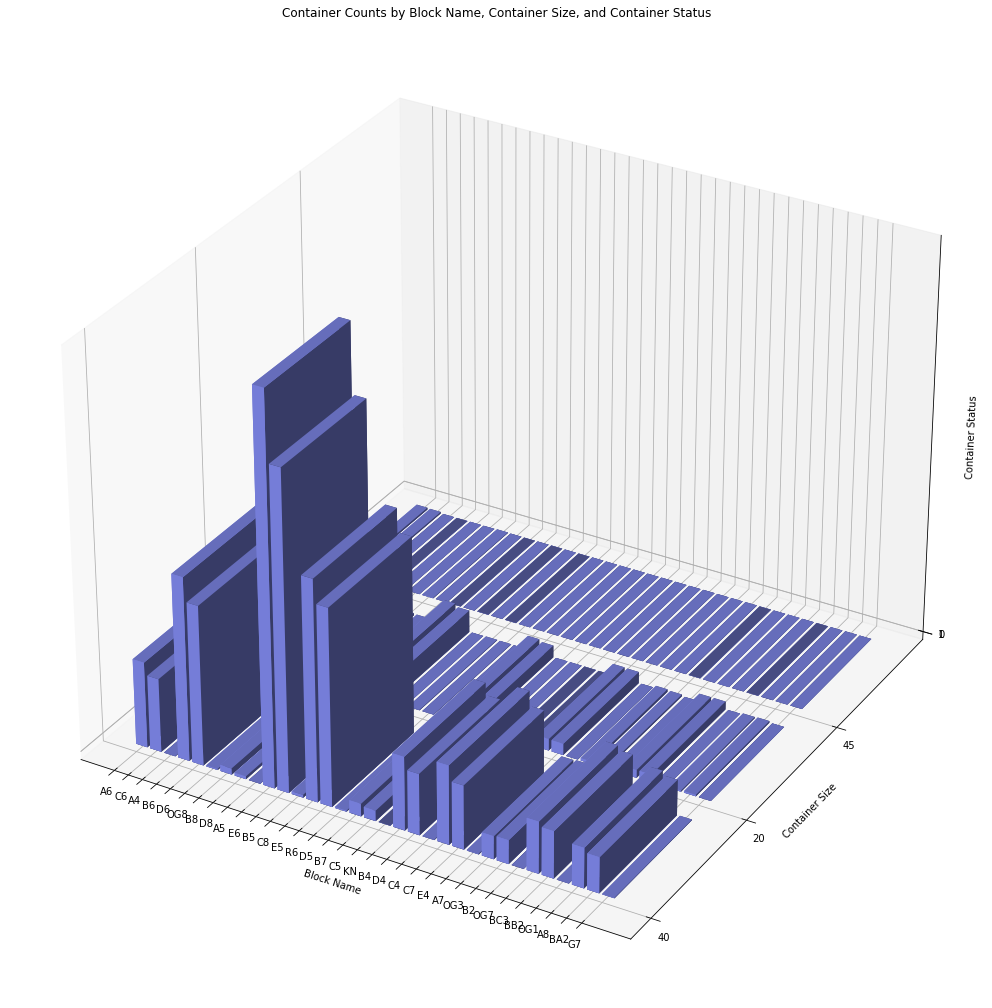

In [114]:
############################################
# Extract the relevant columns from the data
block_name = ldf['BlockName'].unique()
container_sizes = ldf['ContainerSize'].unique()
container_status = ldf['ContainerStatus'].unique()

##############################################################################################
# Generate container counts for each combination of QCNo, Container Size, and Container Status
container_counts = np.zeros((len(block_name), len(container_sizes), len(container_status)))

for i, block in enumerate(block_name):
    for j, size in enumerate(container_sizes):
        for k, status in enumerate(container_status):
            count = len(ldf[(ldf['BlockName'] == block) &
                             (ldf['ContainerSize'] == size) &
                             (ldf['ContainerStatus'] == status)])
            container_counts[i, j, k] = count

######################
# Create a 3D bar plot
fig = plt.figure(figsize=[20, 18])
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = np.meshgrid(np.arange(len(block_name)),
                                  np.arange(len(container_sizes)),
                                  np.arange(len(container_status)))

x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = z_pos.flatten()

#######################################################
# Flatten the counts array to match the position arrays
counts = container_counts.flatten()
########################
# Create the 3D bar plot
ax.bar3d(x_pos, y_pos, z_pos, 0.8, 0.8, counts, color='#858EF4')
#######################
# Set labels and titles
ax.set_xticks(np.arange(len(block_name)))
ax.set_yticks(np.arange(len(container_sizes)))
ax.set_zticks(np.arange(len(container_status)))
ax.set_xticklabels(block_name)
ax.set_yticklabels(container_sizes)
ax.set_zticklabels(container_status)
ax.set_xlabel('Block Name')
ax.set_ylabel('Container Size')
ax.set_zlabel('Container Status')
ax.set_title('Container Counts by Block Name, Container Size, and Container Status')

plt.show()


#### 2.3.2 Illustrate the link between Quay Crane, Container Size, and Container Status for loaded containers on the vessel using a 3D bar plot.

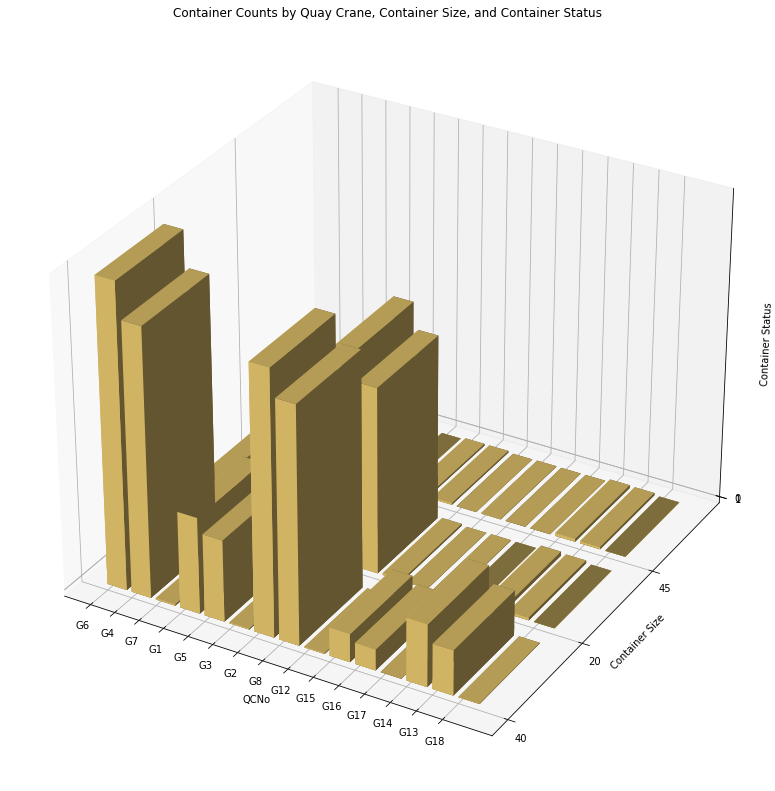

In [115]:
############################################
# Extract the relevant columns from the data
qc_numbers = ldf['QCNo'].unique()
container_sizes = ldf['ContainerSize'].unique()
container_status = ldf['ContainerStatus'].unique()

##############################################################################################
# Generate container counts for each combination of QCNo, Container Size, and Container Status
container_counts = np.zeros((len(qc_numbers), len(container_sizes), len(container_status)))

for i, qcno in enumerate(qc_numbers):
    for j, size in enumerate(container_sizes):
        for k, status in enumerate(container_status):
            count = len(ldf[(ldf['QCNo'] == qcno) &
                             (ldf['ContainerSize'] == size) &
                             (ldf['ContainerStatus'] == status)])
            container_counts[i, j, k] = count

######################
# Create a 3D bar plot
fig = plt.figure(figsize=[16, 14])
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = np.meshgrid(np.arange(len(qc_numbers)),
                                  np.arange(len(container_sizes)),
                                  np.arange(len(container_status)))

x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = z_pos.flatten()

#######################################################
# Flatten the counts array to match the position arrays
counts = container_counts.flatten()

########################
# Create the 3D bar plot
ax.bar3d(x_pos, y_pos, z_pos, 0.8, 0.8, counts, color='#EBCC71')

#######################
# Set labels and titles
ax.set_xticks(np.arange(len(qc_numbers)))
ax.set_yticks(np.arange(len(container_sizes)))
ax.set_zticks(np.arange(len(container_status)))
ax.set_xticklabels(qc_numbers)
ax.set_yticklabels(container_sizes)
ax.set_zticklabels(container_status)
ax.set_xlabel('QCNo')
ax.set_ylabel('Container Size')
ax.set_zlabel('Container Status')
ax.set_title('Container Counts by Quay Crane, Container Size, and Container Status')

plt.show()


#### 2.3.3 Illustrate the link between Container Size, Container Type, and Shipment Type for loaded containers on the vessel using a 3D bar plot.

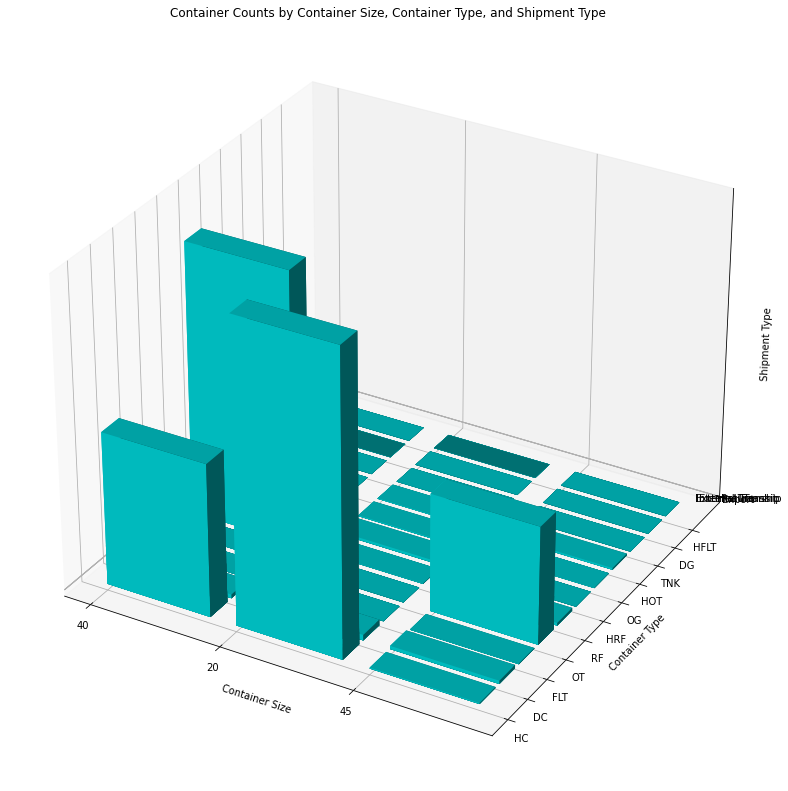

In [116]:
############################################
# Extract the relevant columns from the data
container_sizes = ldf['ContainerSize'].unique()
container_types = ldf['ContainerType'].unique()
shipment_types = ldf['ShipmentType'].unique()

###########################################################################################
# Generate container counts for each combination of container size, type, and shipment type
container_counts = np.zeros((len(container_sizes), len(container_types), len(shipment_types)))

for i, size in enumerate(container_sizes):
    for j, ctype in enumerate(container_types):
        for k, stype in enumerate(shipment_types):
            count = len(ldf[(ldf['ContainerSize'] == size) &
                             (ldf['ContainerType'] == ctype) &
                             (ldf['ShipmentType'] == stype)])
            container_counts[i, j, k] = count

######################
# Create a 3D bar plot
fig = plt.figure(figsize=[16, 14])
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = np.meshgrid(np.arange(len(container_sizes)),
                                  np.arange(len(container_types)),
                                  np.arange(len(shipment_types)))

x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = z_pos.flatten()

#######################################################
# Flatten the counts array to match the position arrays
counts = container_counts.flatten()
########################
# Create the 3D bar plot
ax.bar3d(x_pos, y_pos, z_pos, 0.8, 0.8, counts, color='#00D2D6')
#######################
# Set labels and titles
ax.set_xticks(np.arange(len(container_sizes)))
ax.set_yticks(np.arange(len(container_types)))
ax.set_zticks(np.arange(len(shipment_types)))
ax.set_xticklabels(container_sizes)
ax.set_yticklabels(container_types)
ax.set_zticklabels(shipment_types)
ax.set_xlabel('Container Size')
ax.set_ylabel('Container Type')
ax.set_zlabel('Shipment Type')
ax.set_title('Container Counts by Container Size, Container Type, and Shipment Type')

plt.show()


#### 2.3.4 Illustrate the connection between loaded container's Weight and Port Of Destination, using a bar chart.

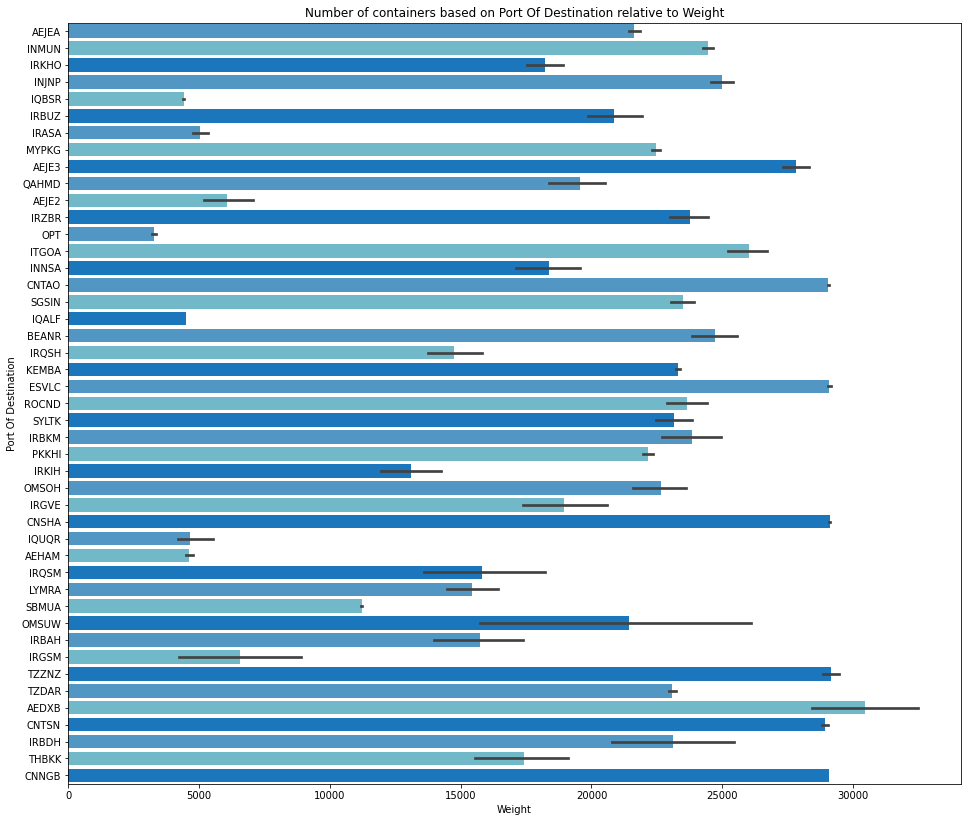

In [117]:
#############################################################################################
# Creating bar chart for connection between loaded container's Weight and Port Of Destination

plt.figure(figsize=[16,14])
custom_colors = ['#3F9AD6', '#62C1D7', '#007AD6']  # Replace with your desired colors
sb.barplot(data=ldf, x='Weight', y='POD', palette=custom_colors)
plt.title('Number of containers based on Port Of Destination relative to Weight')
plt.xlabel('Weight')
plt.ylabel('Port Of Destination')
plt.show()

#### 2.3.5 Illustrate the connection between the loaded container's Weight and different Quay Cranes in the port, using a bar chart.

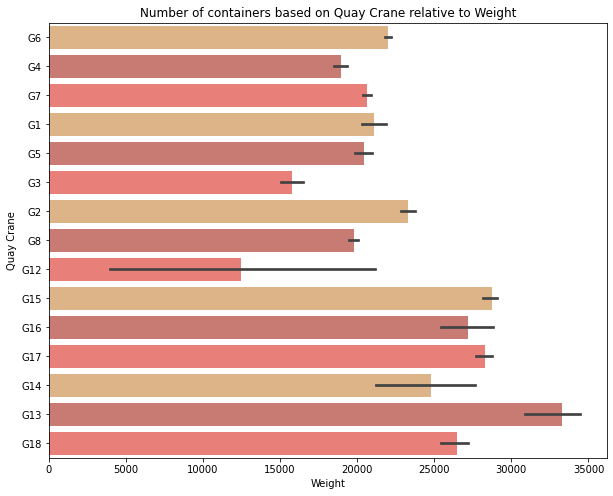

In [118]:
###############################################################################################################
# Creating bar chart for connection between the loaded container's Weight and different Quay Cranes in the port

plt.figure(figsize=[10,8])
custom_colors = ['#EAB57A', '#D67064', '#FA7066']  # Replace with your desired colors
sb.barplot(data=ldf, x='Weight', y='QCNo', palette=custom_colors)
plt.title('Number of containers based on Quay Crane relative to Weight')
plt.xlabel('Weight')
plt.ylabel('Quay Crane')
plt.show()

#### 2.3.6 Illustrate the link between Container Size and Container Type for loaded containers on the vessel using a 2D heatmap diagram.

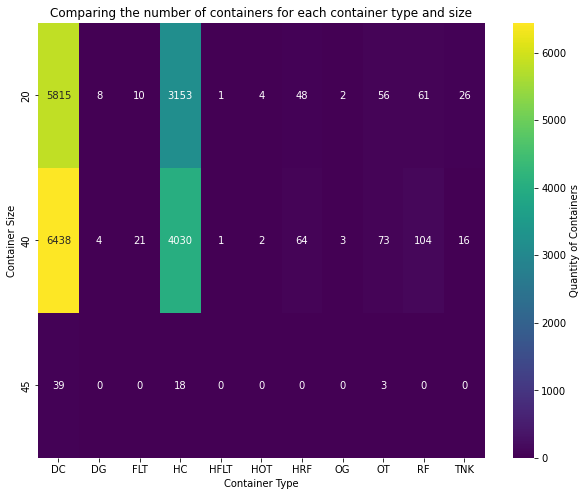

In [119]:
####################################################################################################################
# Creating heatmap to demonstrate link between Container Size and Container Type for loaded containers on the vessel

#########################
# Define a list of colors
my_colors = ['#FF0000', '#00FF00', '#0000FF']

############################################################
# Create a custom colormap using the ListedColormap function
my_cmap = colors.ListedColormap(my_colors)

plt.figure(figsize=[10,8])
 
ct_counts = ldf.groupby(['ContainerSize', 'ContainerType']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'ContainerSize', columns = 'ContainerType', values = 'count').fillna(0)

sb.heatmap(ct_counts, annot = True, fmt = '.0f', cbar_kws = {'label' : 'Quantity of Containers'}, cmap = 'viridis')
plt.title('Comparing the number of containers for each container type and size')
plt.xlabel('Container Type')
plt.ylabel('Container Size');

### 2.4 Data Preprocessing

In this part, we will preprocess data so we create a copy of the primary data file named **ldf** to **ldf_pp**. Preprocess operations that we are going to do fall into some major categories:
- Preprocess **Bay No** as the **class label**;
- Analyzing **Block Name** and **Quay Crane (QCNo)** as the important features;
- Drop more unnecessary features;
- Convert categorical features to numerical features; and
- Drop duplicate rows.

#### 2.4.1 Creating a copy of load dataset for pre-processing:

In [120]:
######################################################
# Creating a copy of Load data file for pre-processing

ldf_pp = ldf.copy()

In [121]:
ldf_pp.head()

,Container,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ArrivalDate,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo,LoadDate
0,AAAU900247-0,A6,24,1,1,2/8/2019 17:16,40,HC,1,Export,32202.0,AEJEA,G6,TDS75,6,2,84,2/11/2019 9:39
1,ACLU963509-0,C6,40,3,1,2/5/2019 9:00,40,HC,1,Export,26384.0,INMUN,G4,156,6,4,86,2/6/2019 15:20
2,AKLU600770-5,A4,25,1,2,4/7/2019 0:39,40,DC,1,External Tranship,3293.0,IRKHO,G7,1204,3,2,4,4/10/2019 2:43
3,AKLU650732-0,B6,30,2,1,4/21/2019 8:56,20,HC,1,Export,30510.0,AEJEA,G4,TDS89,6,3,84,4/23/2019 20:53
4,AKLU650836-9,B6,46,1,1,3/7/2019 20:18,40,HC,1,Export,28740.0,AEJEA,G1,01902J,2,0,84,3/8/2019 18:16


#### 2.4.2 Analyzing some important input features such as Quay Crane, Block Name, and Container Size, plus Bay No as a class label for a specified Voyage Number.

- **IMPORTANT**: In this part, we are going to select one Voyage Number as a sample voyage to analyze its input features and class label and then run Machine Learning models (Random Forest) on this sample voyage. The purpose is to compare the performance of the model for a sample voyage versus the whole Load dataset. The running Random Forest model will be done in part "2.6 Experimental Process".

In [122]:
voyage_counts = ldf_pp['VoyageNo'].value_counts().sort_index(ascending=False)

###########################################################################
# Displaying the Top 30 of Voyage No and their counts to select one of them
print("VoyageNo\tCount")
for voyage, count in voyage_counts.head(30).items():
    print(f"{voyage}\t\t{count}")

VoyageNo	Count
YKT001 WA		23
XPG-1396		3
XPG-1382		464
XPG-1363		218
XPG-1359		281
XPG-1355		229
XPG-1354		192
XPG-1351		165
XPG-1344EA		1
XPG-1342A		2
XPG-1338		108
XPG-1324		229
XPG-1316		23
XPG-1312		6
XPG-1302		3
XPG-1287AA		51
TDS89		52
TDS88		58
TDS87		66
TDS85		62
TDS80		69
TDS78		51
TDS75		60
TDS73		77
TDS72		47
TDS70		85
SUWBND190C		10
SPL1073W		980
SPL-1066		1181
SPL-1059		1


- Based on above output, we select **Voyage Number = SPL1073W with 980 counts** as a sample voyage to analyze different input features and its class label.

- Filter loading data file for **Voyage Number = 'SPL1073W'** named **voyage_filtered_data**:

In [123]:
####################################################################################
# Filter loading data file for Voyage Number = 'SPL1073W' named voyage_filtered_data

#########################
# Selected voyage number:
voyage_number = 'SPL1073W'

##########################################################################
# Filter the data to include only the rows with the selected Voyage number
voyage_filtered_data = ldf_pp[ldf_pp['VoyageNo'] == voyage_number]

- Analyzing the Bay Numbers of **Voyage Number = 'SPL1073W'**:

In [124]:
voyage_filtered_data['BayNo'].value_counts().sort_index(ascending=True)

11    65
13    61
14     2
15    62
17    70
19    66
21    66
23    71
25    64
27    61
29    75
31    71
33    66
35    65
37     5
38     7
39     4
5     20
7     24
9     55
Name: BayNo, dtype: int64

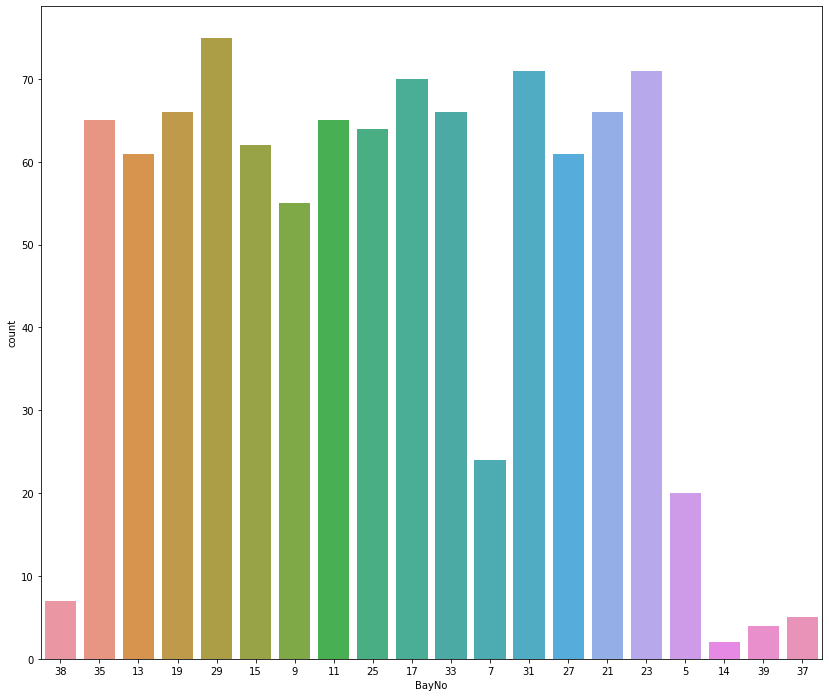

In [125]:
###########################################################################
# Creating a bar chart to show Voyage Number data broken down Bay Positions 

########################################################################
# Check if the filtered DataFrame is not empty before attempting to plot
if not voyage_filtered_data.empty:
    # Plot the count of Bay numbers for the filtered data
    plt.figure(figsize=[14, 12])
    sb.countplot(x='BayNo', data=voyage_filtered_data)
    plt.show()
else:
    print("No data found for the specified Voyage number.")

- Analyzing the Quay Cranes engaged in loading containers on **Voyage Number = 'SPL1073W':**

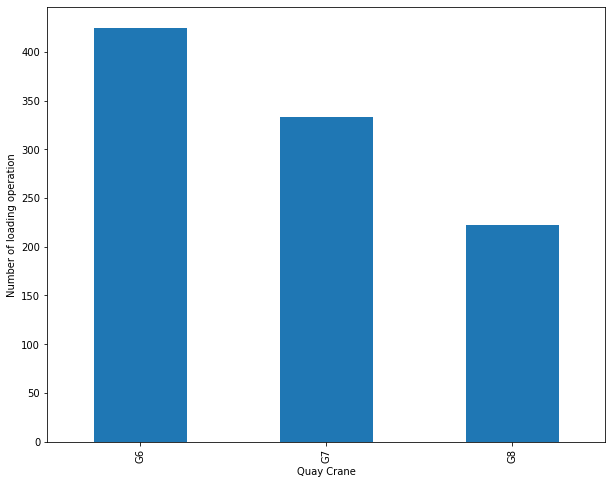

In [126]:
########################################################################
# Creating a bar chart to show Voyage Number data broken down Quay Crane 

plt.figure(figsize=[10,8])
voyage_filtered_data['QCNo'].value_counts().plot(kind='bar')
plt.xlabel('Quay Crane')
plt.ylabel('Number of loading operation')
plt.show()

- Analyzing the Blocks engaged in loading containers for **Voyage Number = 'SPL1073W':**

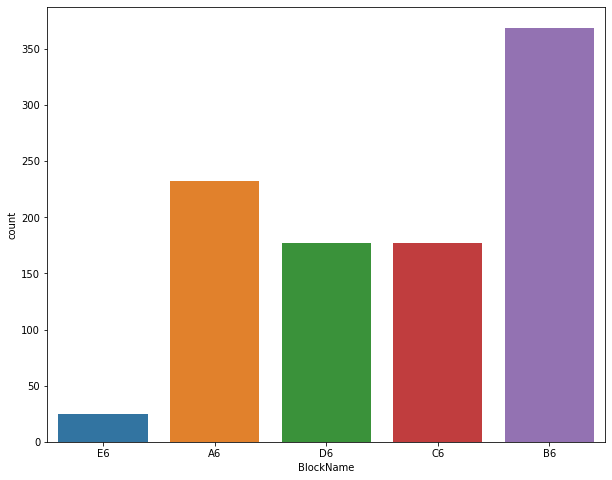

In [127]:
########################################################################
# Creating a bar chart to show Voyage Number data broken down Block Name 

plt.figure(figsize=[10,8])
sb.countplot(x='BlockName', data=voyage_filtered_data)
plt.show()

- Analyzing the Container Sizes of loading containers for **Voyage Number = 'SPL1073W':**

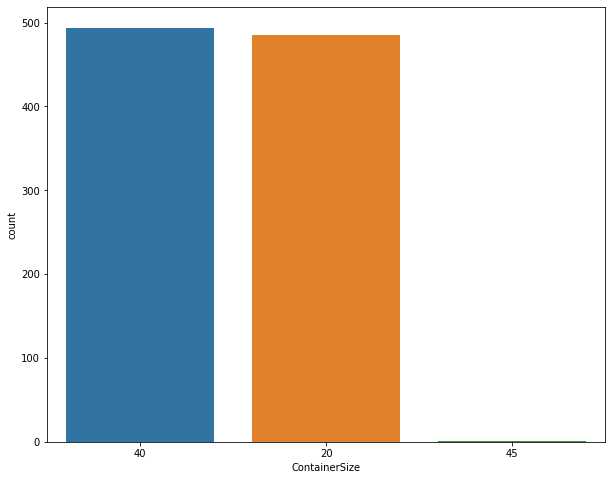

In [128]:
############################################################################
# Creating a bar chart to show Voyage Number data broken down Container Size 

plt.figure(figsize=[10,8])
sb.countplot(x='ContainerSize', data=voyage_filtered_data)
plt.show()

#### 2.4.3 Analyzing Quay Cranes of the berth as one of the most crucial input features.

- Analyzing all Quay Cranes which have been engaged in loading operations for all voyages in the whole Load dataset.

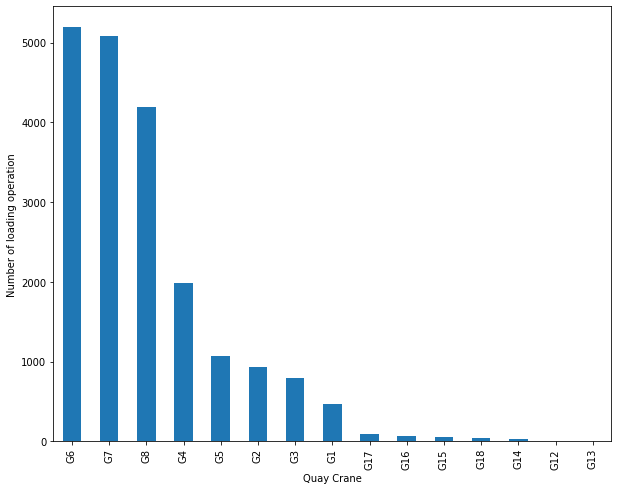

In [129]:
##########################################################################
# Creating a bar chart to show whole Load data file broken down Quay Crane 

plt.figure(figsize=[10,8])
ldf_pp['QCNo'].value_counts().plot(kind='bar')
plt.xlabel('Quay Crane')
plt.ylabel('Number of loading operation')
plt.show()

#### 2.4.4 Analyzing Block Name as one of the most crucial input features:

- Analyzing all Block Names containing containers that have been sent to all vessels in loading operations in the whole dataset.

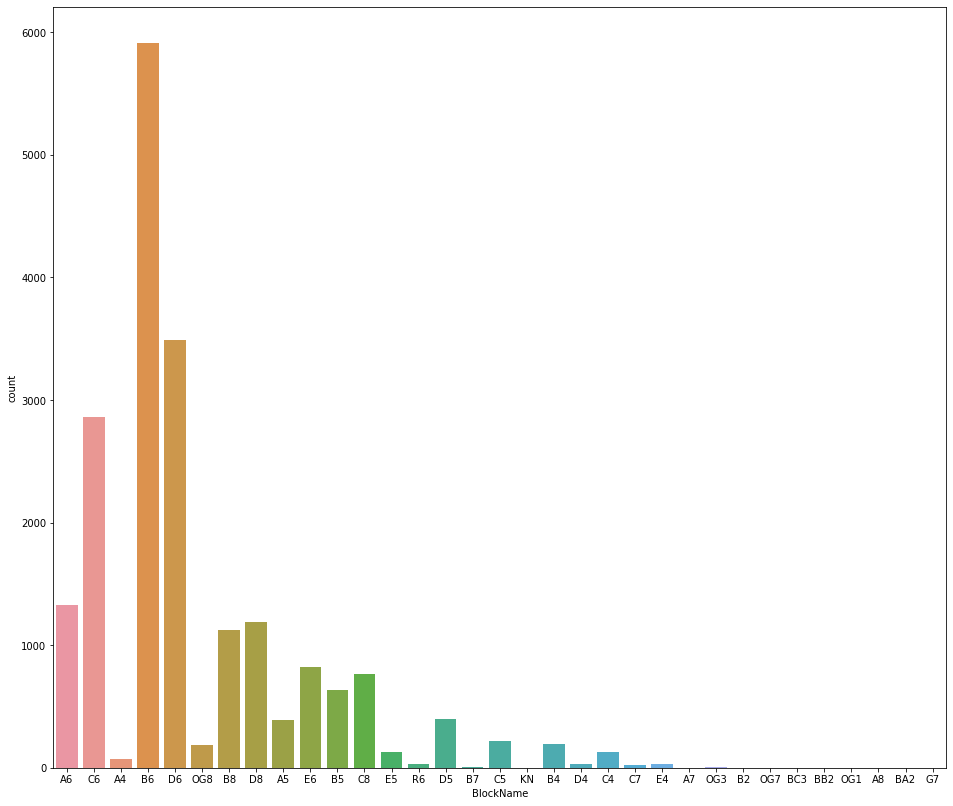

In [130]:
##########################################################################
# Creating a bar chart to show whole Load data file broken down Block Name 

plt.figure(figsize=[16,14])
sb.countplot(x='BlockName', data=ldf_pp)
plt.show()

#### 2.4.4 Analyzing Container Size as an important input feature:

- All container sizes loaded on the vessels in the whole loading operation.

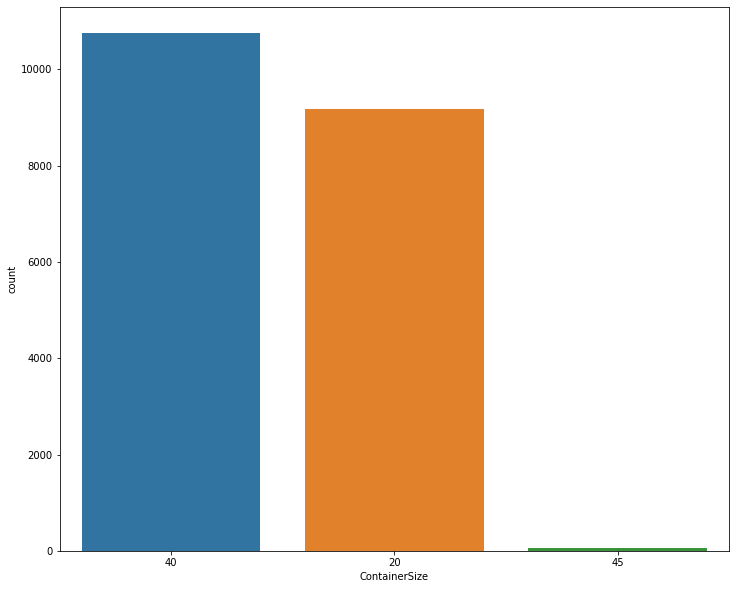

In [131]:
##############################################################################
# Creating a bar chart to show whole Load data file broken down Container Size 

plt.figure(figsize=[12,10])
sb.countplot(x='ContainerSize', data=ldf_pp)
plt.show()

#### 2.4.5 Removing pointless features

In [132]:
ldf_pp.drop('Container', inplace=True, axis=1)
ldf_pp.drop('ArrivalDate', inplace=True, axis=1)
ldf_pp.drop('LoadDate', inplace=True, axis=1)

In [133]:
ldf_pp.head()

,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo
0,A6,24,1,1,40,HC,1,Export,32202.0,AEJEA,G6,TDS75,6,2,84
1,C6,40,3,1,40,HC,1,Export,26384.0,INMUN,G4,156,6,4,86
2,A4,25,1,2,40,DC,1,External Tranship,3293.0,IRKHO,G7,1204,3,2,4
3,B6,30,2,1,20,HC,1,Export,30510.0,AEJEA,G4,TDS89,6,3,84
4,B6,46,1,1,40,HC,1,Export,28740.0,AEJEA,G1,01902J,2,0,84


#### 2.4.6 Converting categorical features of Load dataset to numerical

In [134]:
# Sort the DataFrame by the 'POD' column in ascending order
sorted_data = ldf_pp.sort_values('POD', ascending=True)

# Group the sorted data by the 'POD' column
grouped_data = sorted_data.groupby('POD')

# Get the list of sorted and grouped 'POD' values
sorted_grouped_pods = list(grouped_data.groups.keys())

# Display the sorted and grouped 'POD' values
for pod in sorted_grouped_pods:
    print(pod)

AEDXB
AEHAM
AEJE2
AEJE3
AEJEA
BEANR
CNNGB
CNSHA
CNTAO
CNTSN
ESVLC
INJNP
INMUN
INNSA
IQALF
IQBSR
IQUQR
IRASA
IRBAH
IRBDH
IRBKM
IRBUZ
IRGSM
IRGVE
IRKHO
IRKIH
IRQSH
IRQSM
IRZBR
ITGOA
KEMBA
LYMRA
MYPKG
OMSOH
OMSUW
OPT
PKKHI
QAHMD
ROCND
SBMUA
SGSIN
SYLTK
THBKK
TZDAR
TZZNZ


In [135]:
#################################################
# Converting Port Of Discharge to numerical value

ldf_pp['POD'] = ldf_pp.POD.replace({"AEDXB": 1, "AEHAM": 2, "AEJE2": 3, "AEJE3": 4, "AEJEA": 5,\
                                    "BEANR": 6, "CNNGB": 7, "CNSHA": 8, "CNTAO": 9, "CNTSN": 10,\
                                    "ESVLC": 11, "INJNP": 12, "INMUN": 13, "INNSA": 14, "IQALF": 15,\
                                    "IQBSR": 16, "IQUQR": 17, "IRASA": 18, "IQBSR": 19, "IRBAH": 20,\
                                    "IRBDH": 21, "IRBKM": 22, "IRBUZ": 23, "IRGSM": 24, "IRGVE": 25,\
                                    "IRKHO": 26, "IRKIH": 27, "IRQSH": 28, "IRZBR": 29, "ITGOA": 30,\
                                    "KEMBA": 31, "LYMRA": 32, "MYPKG": 33, "OMSOH": 34, "OMSUW": 35,\
                                    "OPT": 36, "PKKHI": 37, "QAHMD": 38, "ROCND": 39, "SBMUA": 40,\
                                    "SGSIN": 41, "SYLTK": 42, "THBKK": 43, "TZDAR": 44, "TZZNZ": 45, "IRQSM": 46})


In [136]:
##########################################
# Converting Block Name to numerical value
ldf_pp['BlockName'] = ldf_pp.BlockName.replace({"A4": 1, "A5": 2, "A6": 3, "A7": 4, "A8": 5, "B2": 6, "B4": 7, "B5": 8,\
                                      "B6": 9, "B7": 10, "B8": 11, "BA2": 12, "BB2": 13, "BC3": 14, "C4": 15, "C5": 16,\
                                      "C6": 17, "C7": 18, "C8": 19, "D4": 20, "D5": 21,\
                                           "D6": 22, "D8": 23, "E4": 24, "E5": 25, "E6": 26, "G7": 27,\
                                           "KN": 28, "OG1": 29, "OG3": 30,"OG7": 31, "OG8": 32, "R6": 33})


##############################################
# Converting Container Type to numerical value
ldf_pp['ContainerType'] = ldf_pp.ContainerType.replace({"DC": 1, "DG": 2, "FLT": 3, "HC": 4, "HFLT": 5,\
                                                        "HOT": 6, "HRF": 7, "OG": 8, "OT": 9, "RF": 10, "TNK": 11})

#############################################
# Converting Shipment Type to numerical value
ldf_pp['ShipmentType'] = ldf_pp.ShipmentType.replace({"Export": 1, "External Transit": 2,\
                                                      "External Tranship": 3, "Internal Tranship": 4, "Return": 5})

##########################################
# Converting Quay Crane to numerical value
ldf_pp['QCNo'] = ldf_pp.QCNo.replace({"G1": 1, "G2": 2, "G3": 3, "G4": 4, "G5": 5, "G6": 6, "G7": 7, "G8": 8,\
                                      "G9": 9, "G10": 10, "G11": 11, "G12": 12, "G13": 13, "G14": 14, "G15": 15,\
                                      "G16": 16, "G17": 17, "G18": 18})



In [137]:
from sklearn.preprocessing import LabelEncoder

##########################################
# Converting Voyage No. to numerical value

# Initialize the LabelEncoder
encoder = LabelEncoder()

# Fit and transform the 'VoyageNo' column
ldf_pp['VoyageNo'] = encoder.fit_transform(ldf_pp['VoyageNo'])


In [138]:
ldf_pp.head()

,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo
0,3,24,1,1,40,4,1,1,32202.0,5,6,192,6,2,84
1,17,40,3,1,40,4,1,1,26384.0,13,4,28,6,4,86
2,1,25,1,2,40,1,1,3,3293.0,26,7,16,3,2,4
3,9,30,2,1,20,4,1,1,30510.0,5,4,198,6,3,84
4,9,46,1,1,40,4,1,1,28740.0,5,1,0,2,0,84


#### 2.4.7 Dropping duplicate records

In [139]:
duplicates = ldf_pp[ldf_pp.duplicated()]

#################################################
# Creating a CSV file of duplicates for analyzing
duplicates.to_csv('load_duplicates.csv', index=False)

######################
#Numbers of duplicates
len(duplicates)

2

In [140]:
#############################################
# Data file length before dropping duplicates
print("Number of records before dropping duplicates:", len(ldf_pp))

Number of records before dropping duplicates: 20000


In [141]:
#####################
# Dropping duplicates
ldf_pp.drop_duplicates(inplace=True)

In [142]:
############################################
# Data file length after dropping duplicates
print("Number of records after dropping duplicates:", len(ldf_pp))

Number of records after dropping duplicates: 19998


#### 2.4.8 Check features with zero value

In [143]:
features_with_zero_values = ldf_pp.columns[(ldf_pp == 0).any()].tolist()

print(features_with_zero_values)

['VoyageNo']


#### 2.4.9 Data normalization and standardization 

In [144]:
ldf_pp_std = ldf_pp.copy()

In [145]:
################################
# Converting features to integer

ldf_pp_std['BayNo'] = ldf_pp_std['BayNo'].astype(int)
ldf_pp_std['RowNo'] = ldf_pp_std['RowNo'].astype(int)
ldf_pp_std['TierNo'] = ldf_pp_std['TierNo'].astype(int)

In [146]:
###################################################################
# Creating a function to standardize selected features of data file
def z_score_standardization(df, columns):
    for col in columns:
        # Calculate the mean and standard deviation of the column
        mean = np.mean(df[col])
        std_dev = np.std(df[col])
        
        # Standardize the column by subtracting the mean and dividing by the standard deviation
        df[col] = (df[col] - mean) / std_dev

In [147]:
##########################
# Features Standardization 
z_score_standardization(ldf_pp_std, ['BayNo', 'RowNo', 'TierNo'])

In [148]:
################################
# Converting features to integer
ldf_pp_std['BayNo'] = ldf_pp_std['BayNo'].astype(int)
ldf_pp_std['RowNo'] = ldf_pp_std['RowNo'].astype(int)
ldf_pp_std['TierNo'] = ldf_pp_std['TierNo'].astype(int)

ldf_pp_std.head()

,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo
0,3,24,1,1,40,4,1,1,32202.0,5,6,192,-1,0,1
1,17,40,3,1,40,4,1,1,26384.0,13,4,28,-1,0,1
2,1,25,1,2,40,1,1,3,3293.0,26,7,16,-1,0,0
3,9,30,2,1,20,4,1,1,30510.0,5,4,198,-1,0,1
4,9,46,1,1,40,4,1,1,28740.0,5,1,0,-1,-1,1


#### 2.4.10 Creating a data file based on a sample Voyage Number to train model just for one Voyage.

In [149]:
voyage_counts = ldf_pp['VoyageNo'].value_counts().sort_index(ascending=False)
##################################################
# Displaying the list of VoyageNo and their counts
print("VoyageNo\tCount")
for voyage, count in voyage_counts.head(30).items():
    if count >= 100:
        print(f"{voyage}\t\t{count}")

VoyageNo	Count
212		464
211		218
210		281
209		229
208		192
207		165
204		108
203		229
187		980
186		1181


- After pre-processing steps, We select **Voyage Number = 187 with 980 counts** as a sample. We create a new filtered data file named **ldf_voyage**.

In [150]:
# Voyage No. = 187 
# Count = 980 
voyage_number = 187 

#########################################################################
# Filter the data to include only the rows with the desired Voyage number
ldf_voyage = ldf_pp[ldf_pp['VoyageNo'] == voyage_number]

In [151]:
ldf_voyage.head()

,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo
431,26,12,1,4,40,4,1,1,25410.0,31,6,187,38,6,82
537,3,24,1,1,40,1,1,1,23254.0,31,6,187,35,2,6
561,3,24,1,1,40,1,1,1,23254.0,31,8,187,13,6,84
606,22,24,2,1,40,1,1,1,23254.0,31,7,187,19,2,8
784,22,24,2,1,40,1,1,1,23254.0,31,6,187,29,8,84


- **Checking duplicates for one sample voyage.**

In [152]:
duplicates = ldf_voyage[ldf_voyage.duplicated()]
len(duplicates)

0

- **Standardization of one sample voyage data.**

In [153]:
ldf_voyage = ldf_voyage.copy()

In [154]:
################################
# Converting features to integer
ldf_voyage.loc[:, 'BayNo'] = ldf_voyage['BayNo'].astype(int)
ldf_voyage.loc[:, 'RowNo'] = ldf_voyage['RowNo'].astype(int)
ldf_voyage.loc[:, 'TierNo'] = ldf_voyage['TierNo'].astype(int)

In [155]:
#########################
# Feature standardization
ldf_pp_v = z_score_standardization(ldf_voyage, ['BayNo', 'RowNo', 'TierNo'])

In [156]:
################################
# Converting features to integer
ldf_voyage['BayNo'] = ldf_voyage['BayNo'].astype(int)
ldf_voyage['RowNo'] = ldf_voyage['RowNo'].astype(int)
ldf_voyage['TierNo'] = ldf_voyage['TierNo'].astype(int)

ldf_voyage.head()

,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo
431,26,12,1,4,40,4,1,1,25410.0,31,6,187,1,0,1
537,3,24,1,1,40,1,1,1,23254.0,31,6,187,1,-1,0
561,3,24,1,1,40,1,1,1,23254.0,31,8,187,-1,0,1
606,22,24,2,1,40,1,1,1,23254.0,31,7,187,0,-1,0
784,22,24,2,1,40,1,1,1,23254.0,31,6,187,0,0,1


### 2.5 Experimental Process

#### 2.5.1 Running Random Forest classifier just for one sample Voyage (Voyage Number = 187)

In [157]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

################################################
# Separate the target variable from the features
X = ldf_voyage.drop('BayNo', axis=1)
y = ldf_voyage['BayNo']

###############################################
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#############################################################################
# Initialize the RandomForestClassifier model and fit it to the training data
rf_one_voyage = RandomForestClassifier(random_state=42)
rf_one_voyage.fit(X_train, y_train)

####################################################
# Predict the target variable using the training set
y_train_pred = rf_one_voyage.predict(X_train)

###################################################
# Predict the target variable using the testing set
y_test_pred = rf_one_voyage.predict(X_test)

##########
# ACCURACY
#########################################################
# Calculate the accuracy of the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
#########################################################
# Calculate the accuracy of the model on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)

###############################
# PRECISION, RECALL, & F1 SCORE
###############################################################
# Calculate precision, recall, and F1 score on the training set
train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=1)
train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=1)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
##############################################################
# Calculate precision, recall, and F1 score on the testing set
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=1)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')


print("Random Forest Algorithm for sample voyage:")
print("-------------------")
print("Accuracy on training set:", train_accuracy)
print("Accuracy on testing set:", test_accuracy)
print("-------------------")
print("Precision on training set:", train_precision)
print("Precision on testing set:", test_precision)
print("-------------------")
print("Recall on training set:", train_recall)
print("Recall on testing set:", test_recall)
print("-------------------")
print("F1 score on training set:", train_f1)
print("F1 score on testing set:", test_f1)


Random Forest Algorithm for sample voyage:
-------------------
Accuracy on training set: 0.9719387755102041
Accuracy on testing set: 0.8163265306122449
-------------------
Precision on training set: 0.9680015338256934
Precision on testing set: 0.8050934880722114
-------------------
Recall on training set: 0.9739143135024141
Recall on testing set: 0.8355555555555556
-------------------
F1 score on training set: 0.9708580385999741
F1 score on testing set: 0.8147987737593133


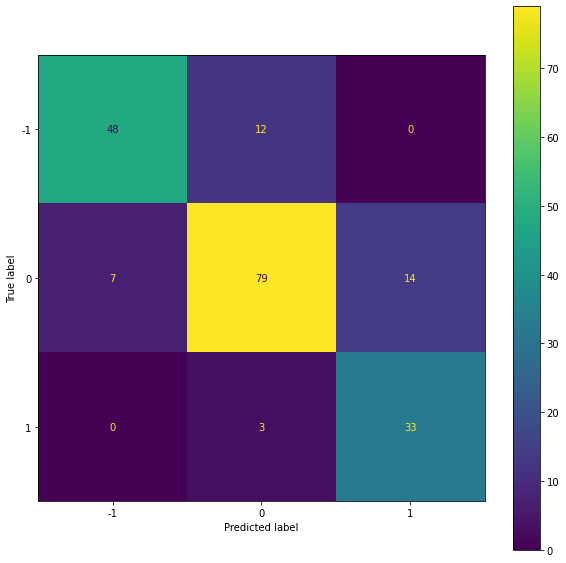

In [158]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
###################################################
# Predict the target variable using the testing set
y_test_pred = rf_one_voyage.predict(X_test)

################################
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

##################################################################
# Get the unique classes from the true labels and predicted labels
classes = np.unique(np.concatenate((y_test, y_test_pred)))

###########################
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax)
plt.show()


#### 2.5.2 Running Random Forest Classifier for whole Load dataset

In [159]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

################################################
# Separate the target variable from the features
X = ldf_pp_std.drop('BayNo', axis=1)
y = ldf_pp_std['BayNo']

###############################################
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#############################################################################
# Initialize the RandomForestClassifier model and fit it to the training data
rf_load = RandomForestClassifier(random_state=42)
rf_load.fit(X_train, y_train)

####################################################
# Predict the target variable using the training set
y_train_pred = rf_load.predict(X_train)

###################################################
# Predict the target variable using the testing set
y_test_pred = rf_load.predict(X_test)

##########
# ACCURACY
#########################################################
# Calculate the accuracy of the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
#########################################################
# Calculate the accuracy of the model on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)

###############################
# PRECISION, RECALL, & F1 SCORE
###############################################################
# Calculate precision, recall, and F1 score on the training set
train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=1)
train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=1)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
##############################################################
# Calculate precision, recall, and F1 score on the testing set
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=1)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')


print("Random Forest Algorithm for whole Load dataset:")
print("-------------------")
print("Accuracy on training set:", train_accuracy)
print("Accuracy on testing set:", test_accuracy)
print("-------------------")
print("Precision on training set:", train_precision)
print("Precision on testing set:", test_precision)
print("-------------------")
print("Recall on training set:", train_recall)
print("Recall on testing set:", test_recall)
print("-------------------")
print("F1 score on training set:", train_f1)
print("F1 score on testing set:", test_f1)


Random Forest Algorithm for whole Load dataset:
-------------------
Accuracy on training set: 0.9783722965370671
Accuracy on testing set: 0.834
-------------------
Precision on training set: 0.985164970942132
Precision on testing set: 0.8560776496199842
-------------------
Recall on training set: 0.981370917827023
Recall on testing set: 0.8329374233763893
-------------------
F1 score on training set: 0.9832565549376333
F1 score on testing set: 0.8416482525296111


In [160]:
#########################################
# Printing Prediction for the sample data
predictions = rf_load.predict([[17,40,1,4,20,4,1,1,30410.0,5,2,191,0,1], [22,18,2,2,40,10,1,1,27570.0,12,7,97,0,1],\
                               [26,35,4,3,20,4,1,1,30158.0,5,5,118,0,1], [11,14,1,1,40,9,0,1,3750.0,5,6,29,1,1],\
                              [2,38,1,1,40,4,1,3,30710.0,23,6,172,0,0], [9,30,6,1,40,1,1,1,18238.0,12,5,68,0,1],\
                              [17,22,4,4,20,10,1,1,31210.0,4,7,53,-1,1]])
predictions

############################################
# Expected Answers: [-1,0,0,1,0,-1,-1]

C:\Users\Kavehoda\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([ 0,  0,  0,  1,  0, -1, -1])

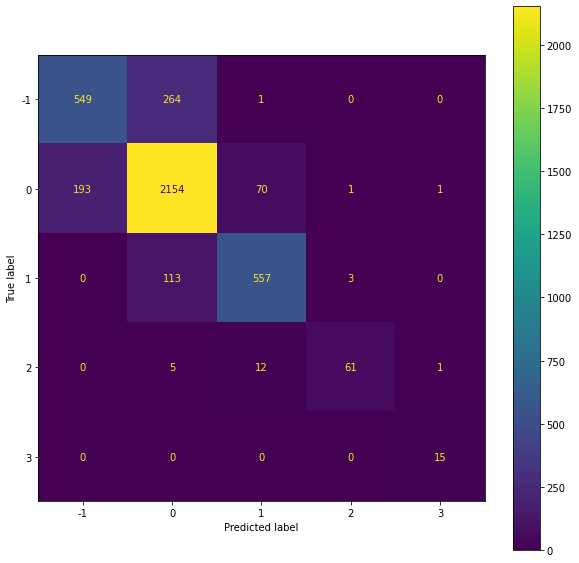

In [161]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
###################################################
# Predict the target variable using the testing set
y_test_pred = rf_load.predict(X_test)

################################
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

##################################################################
# Get the unique classes from the true labels and predicted labels
classes = np.unique(np.concatenate((y_test, y_test_pred)))

###########################
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax)
plt.show()


#### 2.5.3 Running Decision Tree Classifier for whole Load dataset

In [162]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

################################################
# Separate the target variable from the features
X = ldf_pp_std.drop('BayNo', axis=1)
y = ldf_pp_std['BayNo']

###############################################
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#############################################################################
# Initialize the DecisionTreeClassifier model and fit it to the training data
dt_load = DecisionTreeClassifier(random_state=42)
dt_load.fit(X_train, y_train)

####################################################
# Predict the target variable using the training set
y_train_pred = dt_load.predict(X_train)
###################################################
# Predict the target variable using the testing set
y_test_pred = dt_load.predict(X_test)

##########
# ACCURACY
# Calculate the accuracy of the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
########################################################
# Calculate the accuracy of the model on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)

#################################
# precision, recall, and F1 score
# Calculate precision, recall, and F1 score on the training set
train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=1)
train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=1)
train_f1 = f1_score(y_train, y_train_pred, average='macro')

# Calculate precision, recall, and F1 score on the testing set
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=1)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Decision Tree Algorithm for whole Load dataset:")
print("-------------------")
print("Accuracy on training set:", train_accuracy)
print("Accuracy on testing set:", test_accuracy)
print("-------------------")
print("Precision on training set:", train_precision)
print("Precision on testing set:", test_precision)
print("-------------------")
print("Recall on training set:", train_recall)
print("Recall on testing set:", test_recall)
print("-------------------")
print("F1 score on training set:", train_f1)
print("F1 score on testing set:", test_f1)


Decision Tree Algorithm for whole Load dataset:
-------------------
Accuracy on training set: 0.9783722965370671
Accuracy on testing set: 0.814
-------------------
Precision on training set: 0.9851490140653251
Precision on testing set: 0.8127872189374152
-------------------
Recall on training set: 0.9816789189624942
Recall on testing set: 0.8151280310029474
-------------------
F1 score on training set: 0.9833353443948749
F1 score on testing set: 0.8134631172162512


In [163]:
#########################################
# Printing Prediction for the sample data
predictions = dt_load.predict([[17,40,1,4,20,4,1,1,30410.0,5,2,191,0,1], [22,18,2,2,40,10,1,1,27570.0,12,7,97,0,1],\
                               [26,35,4,3,20,4,1,1,30158.0,5,5,118,0,1], [11,14,1,1,40,9,0,1,3750.0,5,6,29,1,1],\
                              [2,38,1,1,40,4,1,3,30710.0,23,6,172,0,0], [9,30,6,1,40,1,1,1,18238.0,12,5,68,0,1],\
                              [17,22,4,4,20,10,1,1,31210.0,4,7,53,-1,1]])
predictions

############################################
# Expected Answers: [-1,0,0,1,0,-1,-1]

C:\Users\Kavehoda\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([ 0,  0,  0,  1,  0, -1, -1])

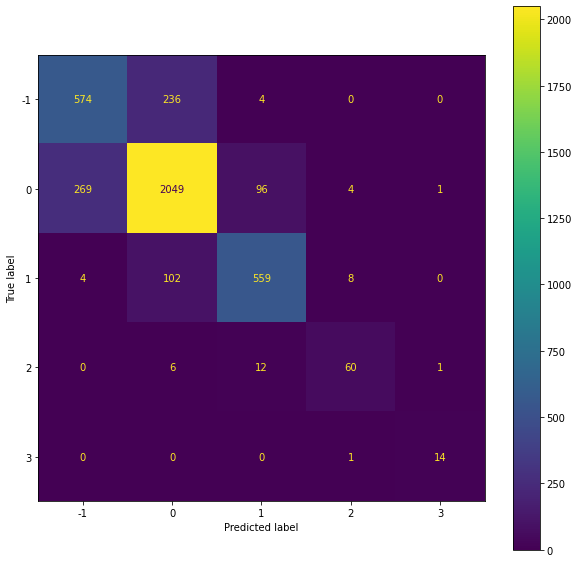

In [164]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
###################################################
# Predict the target variable using the testing set
y_test_pred = dt_load.predict(X_test)

################################
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

##################################################################
# Get the unique classes from the true labels and predicted labels
classes = np.unique(np.concatenate((y_test, y_test_pred)))

###########################
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax)
plt.show()


#### 2.5.4 Running AdaBoost Classifier for whole Load dataset

In [165]:
from sklearn.ensemble import AdaBoostClassifier

################################################
# Separate the target variable from the features
X = ldf_pp_std.drop('BayNo', axis=1)
y = ldf_pp_std['BayNo']

###############################################
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#########################################################################
# Initialize the AdaBoostClassifier model and fit it to the training data
ada_load = AdaBoostClassifier(random_state=42)
ada_load.fit(X_train, y_train)
####################################################
# Predict the target variable using the training set
y_train_pred = ada_load.predict(X_train)
###################################################
# Predict the target variable using the testing set
y_test_pred = ada_load.predict(X_test)

##########
# ACCURACY
#########################################################
# Calculate the accuracy of the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
########################################################
# Calculate the accuracy of the model on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)

#################################
# precision, recall, and F1 score
###############################################################
# Calculate precision, recall, and F1 score on the training set
train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=1)
train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=1)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
##############################################################
# Calculate precision, recall, and F1 score on the testing set
test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=1)
test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=1)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Ada Boost Algorithm for whole Load dataset:")
print("-------------------")
print("Accuracy on training set:", train_accuracy)
print("Accuracy on testing set:", test_accuracy)
print("-------------------")
print("Precision on training set:", train_precision)
print("Precision on testing set:", test_precision)
print("-------------------")
print("Recall on training set:", train_recall)
print("Recall on testing set:", test_recall)
print("-------------------")
print("F1 score on training set:", train_f1)
print("F1 score on testing set:", test_f1)


Ada Boost Algorithm for whole Load dataset:
-------------------
Accuracy on training set: 0.29097387173396677
Accuracy on testing set: 0.28425
-------------------
Precision on training set: 0.42013452254792105
Precision on testing set: 0.4030912585928899
-------------------
Recall on training set: 0.3868505492676225
Recall on testing set: 0.4095453873430962
-------------------
F1 score on training set: 0.31090303177125544
F1 score on testing set: 0.31340092058654634


In [166]:
#########################################
# Printing Prediction for the sample data
predictions = ada_load.predict([[17,40,1,4,20,4,1,1,30410.0,5,2,191,0,1], [22,18,2,2,40,10,1,1,27570.0,12,7,97,0,1],\
                               [26,35,4,3,20,4,1,1,30158.0,5,5,118,0,1], [11,14,1,1,40,9,0,1,3750.0,5,6,29,1,1],\
                              [2,38,1,1,40,4,1,3,30710.0,23,6,172,0,0], [9,30,6,1,40,1,1,1,18238.0,12,5,68,0,1],\
                              [17,22,4,4,20,10,1,1,31210.0,4,7,53,-1,1]])
predictions

############################################
# Expected Answers: [-1,0,0,1,0,-1,-1]

C:\Users\Kavehoda\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


array([-1,  2, -1, -1, -1, -1, -1])

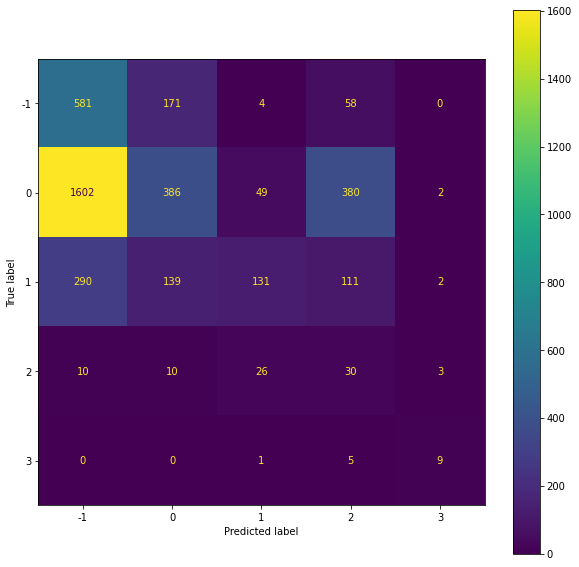

In [167]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
###################################################
# Predict the target variable using the testing set
y_test_pred = ada_load.predict(X_test)

################################
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

##################################################################
# Get the unique classes from the true labels and predicted labels
classes = np.unique(np.concatenate((y_test, y_test_pred)))
###########################
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax)
plt.show()


### 2.6 Feature Importance of Load dataset

In [168]:
from sklearn.preprocessing import LabelEncoder

In [169]:
#############################################
# Creating a data file for Feature Importance
ldf_fi = ldf.copy()

In [170]:
ldf_fi.head()

,Container,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ArrivalDate,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo,RowNo,TierNo,LoadDate
0,AAAU900247-0,A6,24,1,1,2/8/2019 17:16,40,HC,1,Export,32202.0,AEJEA,G6,TDS75,6,2,84,2/11/2019 9:39
1,ACLU963509-0,C6,40,3,1,2/5/2019 9:00,40,HC,1,Export,26384.0,INMUN,G4,156,6,4,86,2/6/2019 15:20
2,AKLU600770-5,A4,25,1,2,4/7/2019 0:39,40,DC,1,External Tranship,3293.0,IRKHO,G7,1204,3,2,4,4/10/2019 2:43
3,AKLU650732-0,B6,30,2,1,4/21/2019 8:56,20,HC,1,Export,30510.0,AEJEA,G4,TDS89,6,3,84,4/23/2019 20:53
4,AKLU650836-9,B6,46,1,1,3/7/2019 20:18,40,HC,1,Export,28740.0,AEJEA,G1,01902J,2,0,84,3/8/2019 18:16


In [171]:
####################################################
# Dropping pointless features for Feature Importance

ldf_fi.drop('Container', inplace=True, axis=1)
ldf_fi.drop('ArrivalDate', inplace=True, axis=1)
ldf_fi.drop('RowNo', inplace=True, axis=1)
ldf_fi.drop('TierNo', inplace=True, axis=1)
ldf_fi.drop('LoadDate', inplace=True, axis=1)

In [172]:
ldf_fi.columns.to_list()

['BlockName',
 'YardZoneRow',
 'YardZoneTier',
 'YardZoneLevel',
 'ContainerSize',
 'ContainerType',
 'ContainerStatus',
 'ShipmentType',
 'Weight',
 'POD',
 'QCNo',
 'VoyageNo',
 'BayNo']

In [173]:
ldf_fi.head()

,BlockName,YardZoneRow,YardZoneTier,YardZoneLevel,ContainerSize,ContainerType,ContainerStatus,ShipmentType,Weight,POD,QCNo,VoyageNo,BayNo
0,A6,24,1,1,40,HC,1,Export,32202.0,AEJEA,G6,TDS75,6
1,C6,40,3,1,40,HC,1,Export,26384.0,INMUN,G4,156,6
2,A4,25,1,2,40,DC,1,External Tranship,3293.0,IRKHO,G7,1204,3
3,B6,30,2,1,20,HC,1,Export,30510.0,AEJEA,G4,TDS89,6
4,B6,46,1,1,40,HC,1,Export,28740.0,AEJEA,G1,01902J,2


In [174]:
##############################################################################################################
# Iterating through DataFrame columns, applying label encoding to convert categorical data into numeric values.
for col in ldf_fi.columns:
    if ldf_fi[col].dtypes == 'object':
        encoder = LabelEncoder()
        ldf_fi[col] = encoder.fit_transform(ldf_fi[col])

In [175]:
#####################
# Partioning the data
Xc = ldf_fi.drop('BayNo', axis=1)
yc = ldf_fi['BayNo']

###################################
# Splitting to training and testing
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

In [176]:
#################################################
# Random Forest Classifier for feature importance
rf_fi_load = RandomForestClassifier()
rf_fi_load.fit(Xc_train, yc_train)

#########################################################
# View a list of the features and their importance scores
print('\nFeatures Importance:')
feat_imp = pd.DataFrame(zip(Xc.columns.tolist(), rf_fi_load.feature_importances_ * 100), columns=['feature', 'importance'])
feat_imp


Features Importance:


,feature,importance
0,BlockName,6.774010
1,YardZoneRow,21.248180
2,YardZoneTier,7.996095
3,YardZoneLevel,5.584565
4,ContainerSize,5.741154
5,ContainerType,3.706287
6,ContainerStatus,0.410692
7,ShipmentType,1.694232
8,Weight,20.048345
9,POD,6.802217


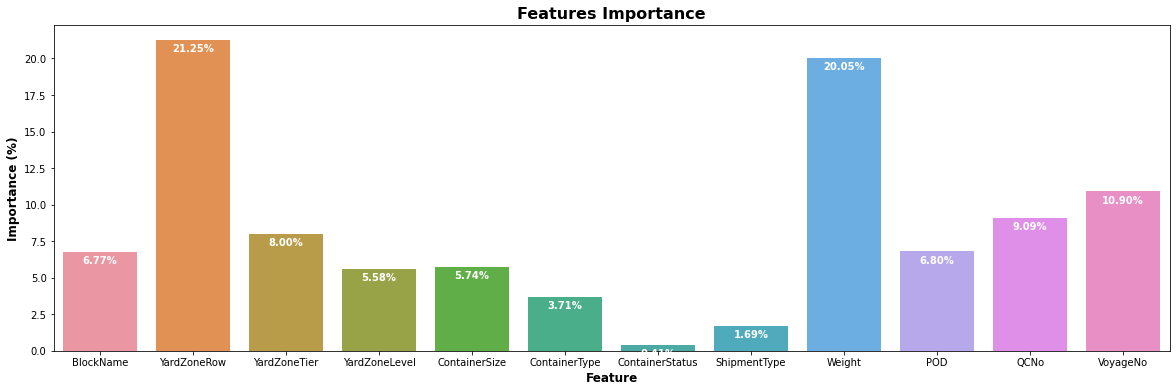

In [177]:
##########################
# Features importance plot
plt.figure(figsize=[20,6])
sb.barplot(data=feat_imp, x='feature', y='importance')
plt.title('Features Importance', weight='bold', fontsize=16)
plt.xlabel('Feature', weight='bold', fontsize=12)
plt.ylabel('Importance (%)', weight='bold', fontsize=12);

#################
# add annotations
impo = feat_imp['importance']
locs, labels = plt.xticks()

for loc, label in zip(locs, labels):
    count = impo[loc]
    pct_string = '{:0.2f}%'.format(count)

    plt.text(loc, count-0.8, pct_string, ha = 'center', color = 'w', weight='bold')